# Week 3 Lab: Demand

Fit the exponential demand equation (Hursh & Silberberg, 2008) to participant
consumption data and analyze the results.

$$\log Q = \log Q_0 + k\,(e^{-\alpha\, Q_0\, C} - 1)$$

In the simplified form used here we fit $\alpha$ per participant with $Q_0$ taken
from consumption at the lowest price and $k$ derived from the span of the data.

Work through each task. Code cells are left blank for you to fill in; see the lab
page for hints and watch out for the `log(0)` issue.

## Setup

Import the libraries you will need: `numpy`, `pandas`, `matplotlib`, `seaborn`, plus `curve_fit` from `scipy.optimize` and the metrics from `scikit-learn`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit

## Task 1: Read in the dataset

Load `participant_data.csv`. Each row is one participant with consumption at 11 price points, plus the true `Q0` and `a` (alpha) values used to generate the data (with noise added).

In [3]:
df = pd.read_csv("participant_data.csv")
df

,participant_id,price_0.01,price_0.05,price_0.25,price_1.00,price_5.00,price_10.00,price_33.00,price_100.00,price_250.00,price_500.00,price_1000.00,Q0,a
0,1,26.602136,26.944272,24.677904,23.672076,14.636682,7.673999,8.860184,11.061818,0.0,0.0,0.0,28.060809,0.222392
1,2,25.486500,17.497575,21.862445,20.960644,14.670700,13.450010,9.303047,8.794391,0.0,0.0,0.0,23.926193,0.065625
2,3,80.992921,91.018292,75.982646,72.418701,47.876094,32.729950,34.682638,34.609209,0.0,0.0,0.0,92.789644,0.243377
3,4,30.978687,29.842977,27.372602,20.653809,18.394334,16.033233,8.613592,8.914916,0.0,0.0,0.0,30.503221,0.097146
4,5,82.734313,76.679180,80.214163,80.859966,39.464999,36.244974,30.439826,33.248904,0.0,0.0,0.0,91.367065,0.211274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,84.489475,83.246396,77.772511,53.558434,43.380771,25.475773,26.537323,26.124654,0.0,0.0,0.0,88.322114,0.185970
96,97,50.687081,47.028110,42.918489,37.863643,26.661466,24.437456,16.834183,20.024537,0.0,0.0,0.0,51.891502,0.147152
97,98,19.824518,21.437660,23.218716,17.157969,15.871363,10.057625,9.657634,7.937757,0.0,0.0,0.0,25.657879,0.145882
98,99,22.271776,18.789937,22.459097,17.887151,10.727652,10.266242,5.874748,6.943184,0.0,0.0,0.0,22.046491,0.189896


## Task 2: Transform the dataset to long form

The price points are stored as separate columns (`price_0.01`, `price_0.05`, ...). Use `melt` to reshape so each row is a single price/consumption observation.

In [4]:
df = df.melt(
    id_vars=['participant_id', 'Q0', 'a'],
    value_vars=[
        'price_0.01', 'price_0.05', 'price_0.25', 'price_1.00',
        'price_5.00', 'price_10.00', 'price_33.00', 'price_100.00',
        'price_250.00', 'price_500.00', 'price_1000.00'
    ])
df

,participant_id,Q0,a,variable,value
0,1,28.060809,0.222392,price_0.01,26.602136
1,2,23.926193,0.065625,price_0.01,25.486500
2,3,92.789644,0.243377,price_0.01,80.992921
3,4,30.503221,0.097146,price_0.01,30.978687
4,5,91.367065,0.211274,price_0.01,82.734313
...,...,...,...,...,...
1095,96,88.322114,0.185970,price_1000.00,0.000000
1096,97,51.891502,0.147152,price_1000.00,0.000000
1097,98,25.657879,0.145882,price_1000.00,0.000000
1098,99,22.046491,0.189896,price_1000.00,0.000000


## Task 3: Transform the price to a numeric value

The `variable` column holds strings like `price_5.00`. Strip the `price_` prefix and cast to float so price can be used numerically.

In [5]:
df['price'] = df['variable'].str.replace('price_', '', regex=False).astype(float)
df

,participant_id,Q0,a,variable,value,price
0,1,28.060809,0.222392,price_0.01,26.602136,0.01
1,2,23.926193,0.065625,price_0.01,25.486500,0.01
2,3,92.789644,0.243377,price_0.01,80.992921,0.01
3,4,30.503221,0.097146,price_0.01,30.978687,0.01
4,5,91.367065,0.211274,price_0.01,82.734313,0.01
...,...,...,...,...,...,...
1095,96,88.322114,0.185970,price_1000.00,0.000000,1000.00
1096,97,51.891502,0.147152,price_1000.00,0.000000,1000.00
1097,98,25.657879,0.145882,price_1000.00,0.000000,1000.00
1098,99,22.046491,0.189896,price_1000.00,0.000000,1000.00


## Task 4: Calculate the parameter k

`k` is the span (in log units) of the consumption data. Compute it from the range of non-zero consumption values across the dataset. (You could also choose a fixed constant; here we derive it from the data.)

In [6]:
def calculate_k(df):
    nonzero_values = df['value'][df['value'] > 0]
    k = np.log(nonzero_values.max() - nonzero_values.min())
    return k

k_value = calculate_k(df)
print("k =", k_value)

k = 4.531466091014856


## Task 5: Create the demand function and a per-participant fitter

Write a function that, for one participant, takes `Q0` from consumption at the lowest price, then uses `curve_fit` to estimate `alpha` for the exponential demand equation. Return alpha, Q0, and goodness-of-fit metrics (R-squared, MAE, RMSE).

In [ ]:
def fit_hursh_demand(participant_data, k_value=1.0):
    """Fit the Hursh demand equation to one participant; estimate alpha."""
    prices = participant_data['price'].values
    consumptions = participant_data['value'].values

    # Q0 = consumption at the lowest price
    Q0_estimate = consumptions[np.argmin(prices)]

    def hursh_fixed_params(price, alpha):
        logQ = np.log(Q0_estimate) + k_value * (np.exp(-alpha * price) - 1)
        return np.exp(logQ)

    try:
        popt, _ = curve_fit(hursh_fixed_params, prices, consumptions,
                            p0=[0.1], bounds=([0.001], [10.0]))
        alpha_estimate = popt[0]
        predicted = hursh_fixed_params(prices, alpha_estimate)
        ss_res = np.sum((consumptions - predicted) ** 2)
        ss_tot = np.sum((consumptions - np.mean(consumptions)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        mae = np.mean(np.abs(consumptions - predicted))
        rmse = np.sqrt(np.mean((consumptions - predicted) ** 2))
        return alpha_estimate, Q0_estimate, r_squared, mae, rmse
    except Exception:
        return None, None, None, None, None


def fit_all_participants(df, k_value=1.0):
    """Loop over participants and fit each one."""
    results = []
    for participant_id in df['participant_id'].unique():
        pdata = df[df['participant_id'] == participant_id][['price', 'value']]
        true_params = df[df['participant_id'] == participant_id][['Q0', 'a']].iloc[0]
        alpha_est, Q0_est, r_sq, mae, rmse = fit_hursh_demand(pdata, k_value)
        results.append({
            'participant_id': participant_id, 'alpha_estimated': alpha_est,
            'Q0_estimated': Q0_est, 'r_squared': r_sq, 'mae': mae, 'rmse': rmse,
            'k_used': k_value, 'alpha_true': true_params['a'], 'Q0_true': true_params['Q0']})
    return pd.DataFrame(results)

## Task 6: Apply the function to each participant

Run the fitter across all participants, passing the `k` you computed in Task 4.

In [8]:
results_df = fit_all_participants(df, k_value=calculate_k(df))
results_df

,participant_id,alpha_estimated,Q0_estimated,r_squared,mae,rmse,k_used,alpha_true,Q0_true
0,1,0.024885,26.602136,0.859942,2.113368,3.890155,4.531466,0.222392,28.060809
1,2,0.013065,25.486500,0.784668,2.974703,4.075421,4.531466,0.065625,23.926193
2,3,0.014049,80.992921,0.841877,8.696574,12.867209,4.531466,0.243377,92.789644
3,4,0.016858,30.978687,0.881410,2.655047,3.918822,4.531466,0.097146,30.503221
4,5,0.018116,82.734313,0.850000,7.655193,12.453748,4.531466,0.211274,91.367065
...,...,...,...,...,...,...,...,...,...
95,96,0.032146,84.489475,0.859330,6.861635,11.764127,4.531466,0.185970,88.322114
96,97,0.018129,50.687081,0.817569,5.270551,7.720962,4.531466,0.147152,51.891502
97,98,0.005776,19.824518,0.898093,1.923288,2.673044,4.531466,0.145882,25.657879
98,99,0.022012,22.271776,0.888979,1.977213,2.787339,4.531466,0.189896,22.046491


## Task 7: Graph and analyze the results

Compare estimated vs. true alpha and look at the distributions of the goodness-of-fit metrics across participants.

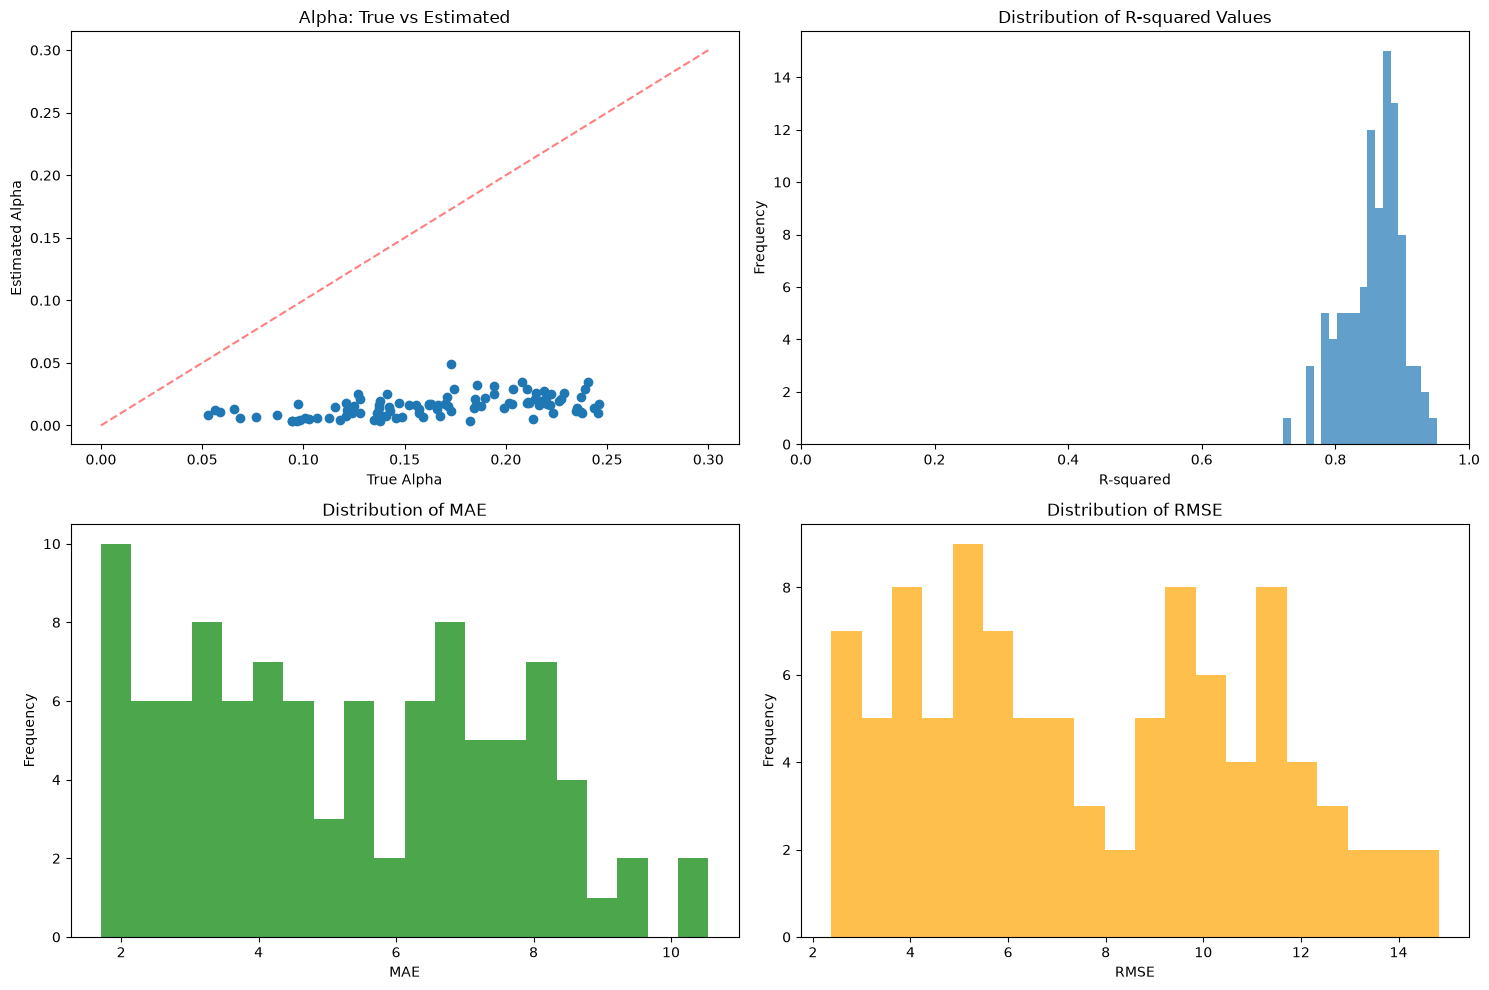

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.scatter(results_df['alpha_true'], results_df['alpha_estimated'])
ax1.plot([0, 0.3], [0, 0.3], 'r--', alpha=0.5)
ax1.set_xlabel('True Alpha'); ax1.set_ylabel('Estimated Alpha')
ax1.set_title('Alpha: True vs Estimated')

ax2.hist(results_df['r_squared'], bins=20, alpha=0.7); ax2.set_xlim(0, 1)
ax2.set_xlabel('R-squared'); ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of R-squared Values')

ax3.hist(results_df['mae'], bins=20, alpha=0.7, color='green')
ax3.set_xlabel('MAE'); ax3.set_ylabel('Frequency'); ax3.set_title('Distribution of MAE')

ax4.hist(results_df['rmse'], bins=20, alpha=0.7, color='orange')
ax4.set_xlabel('RMSE'); ax4.set_ylabel('Frequency'); ax4.set_title('Distribution of RMSE')

plt.tight_layout()
plt.show()

## Task 8: Calculate goodness-of-fit metrics and plot individual fits

For each participant, generate predicted consumption from the fitted parameters, compute R-squared and RMSE, and overlay the fitted curve on the observed data (log price axis).

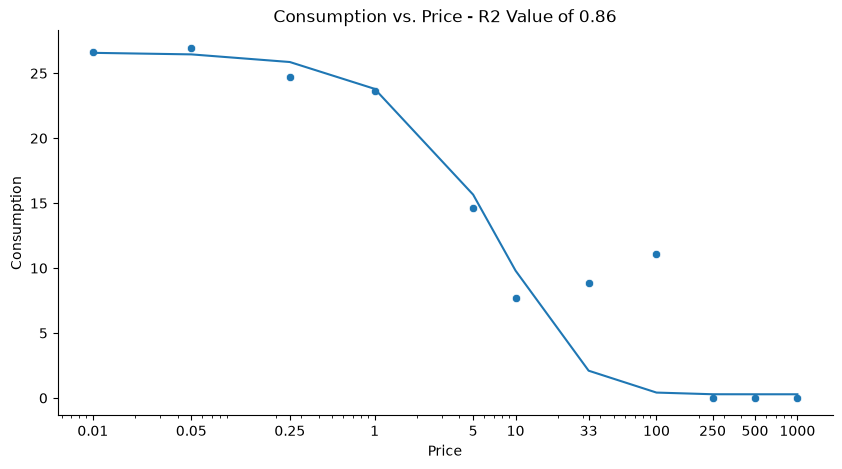

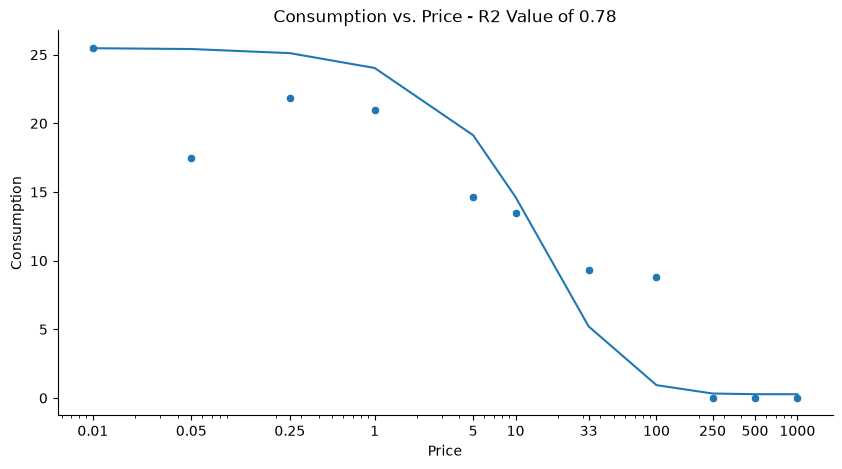

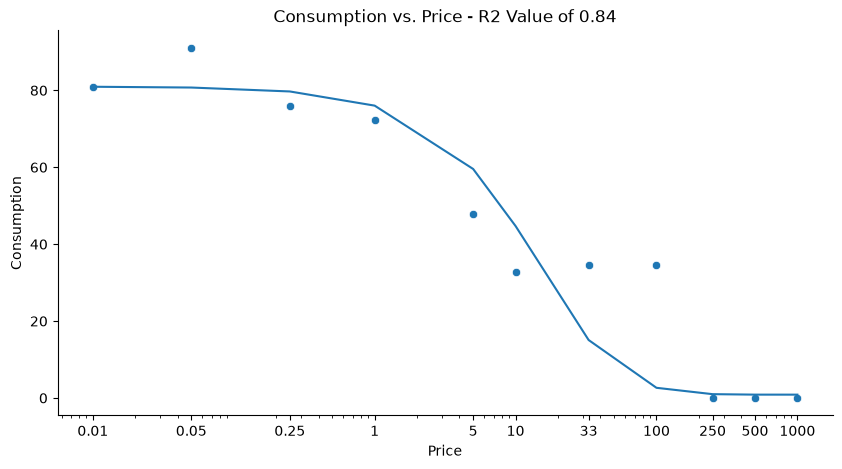

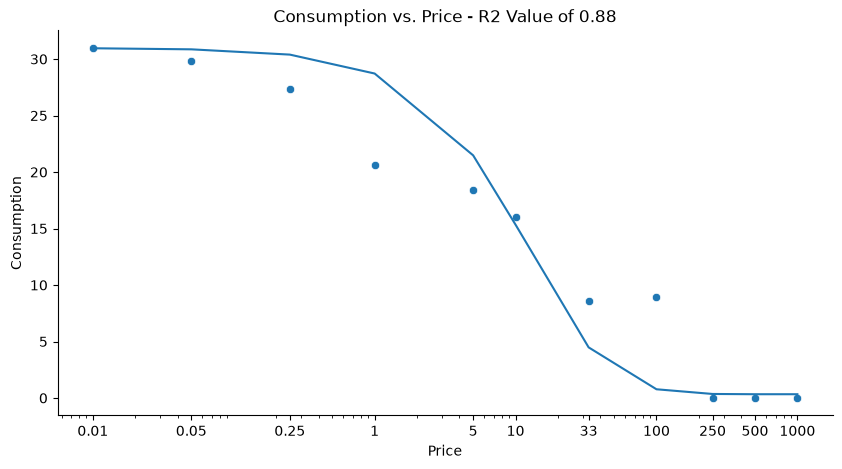

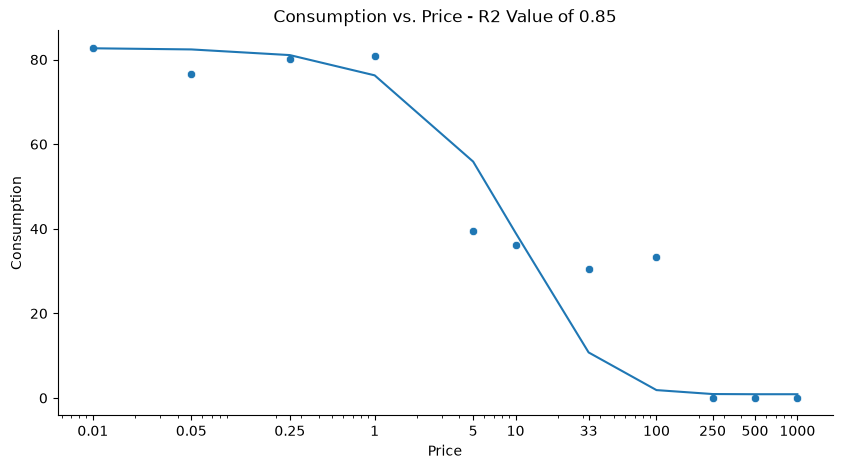

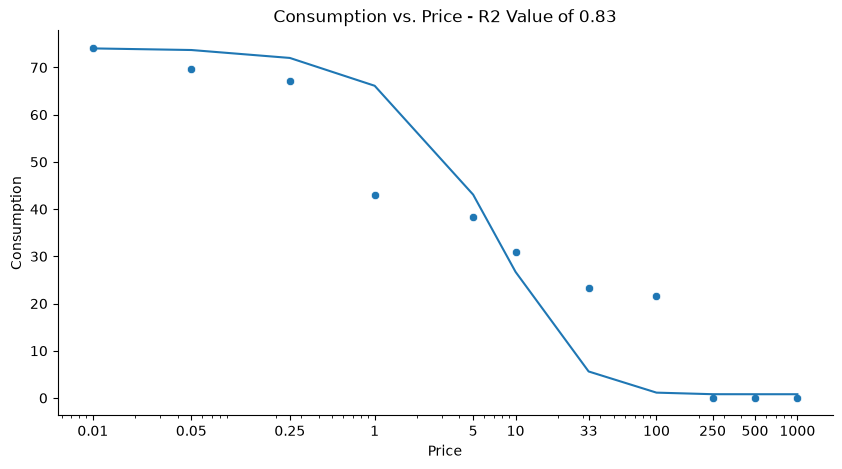

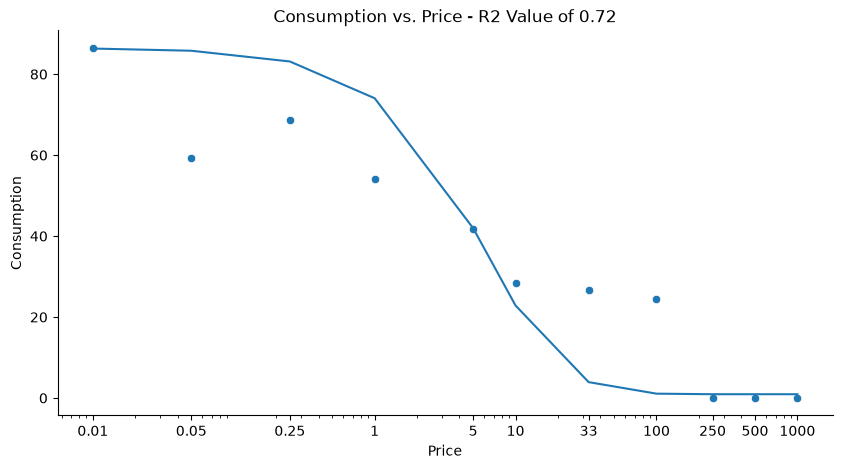

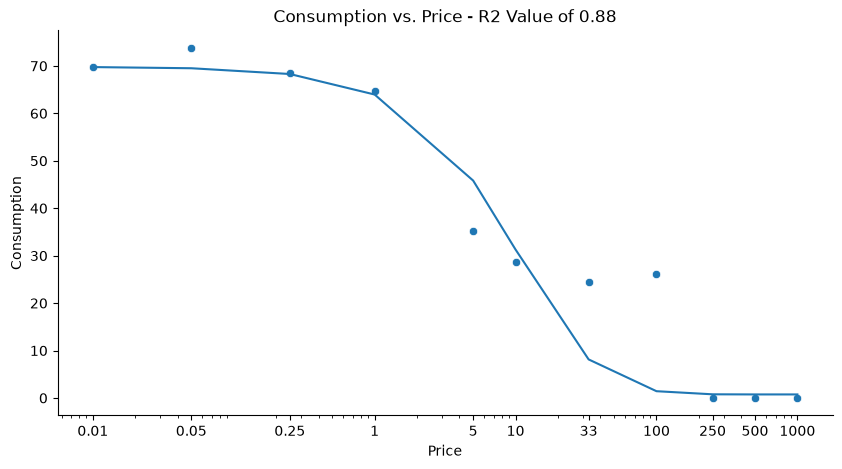

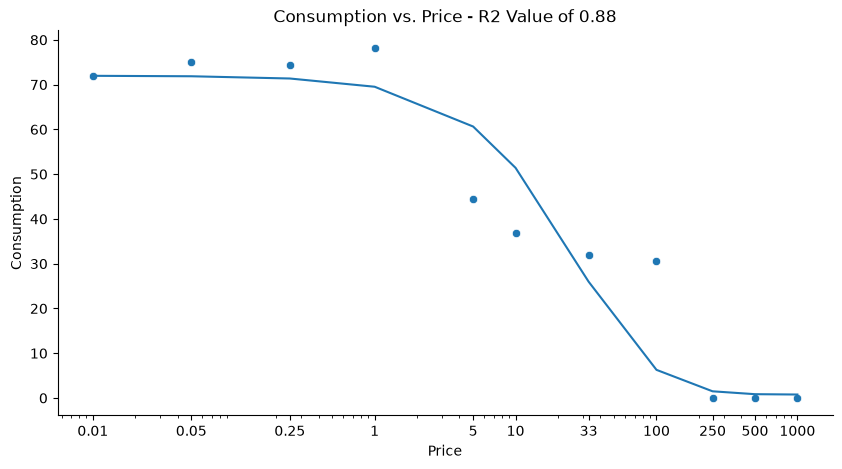

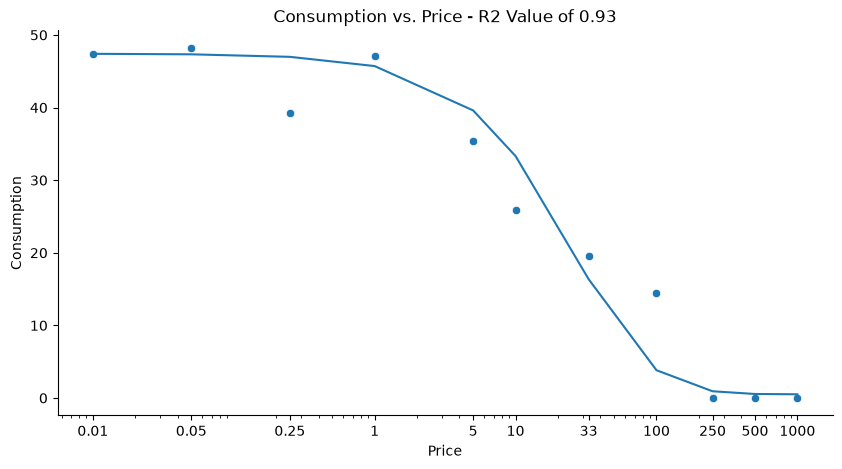

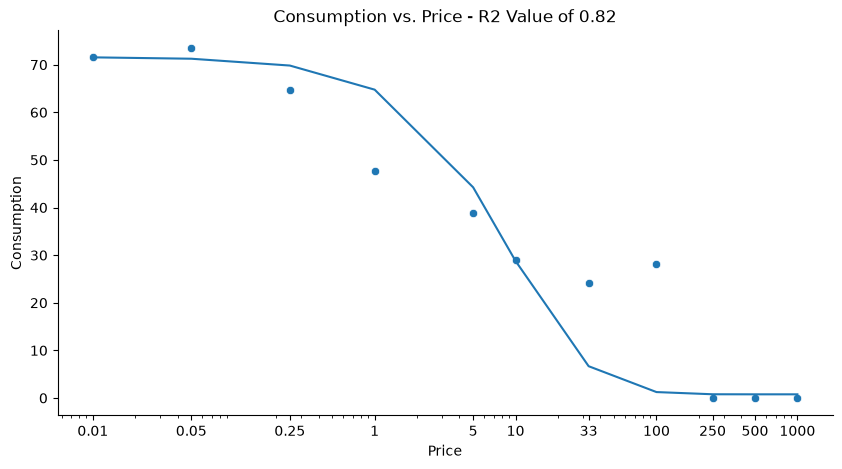

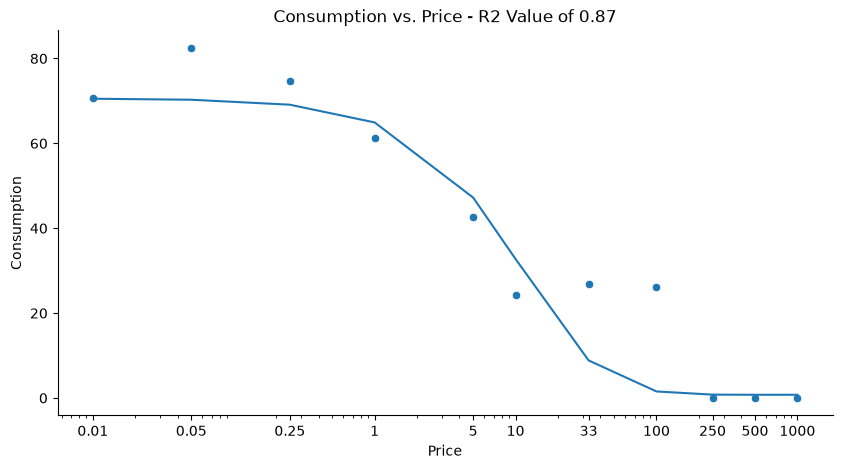

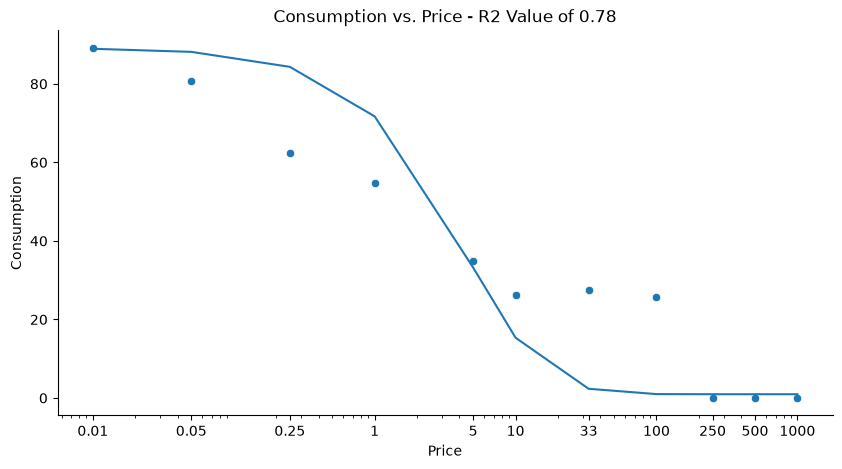

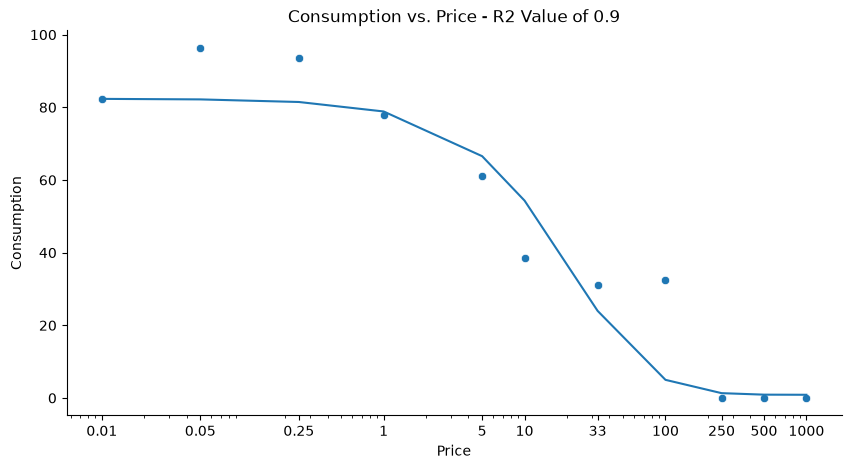

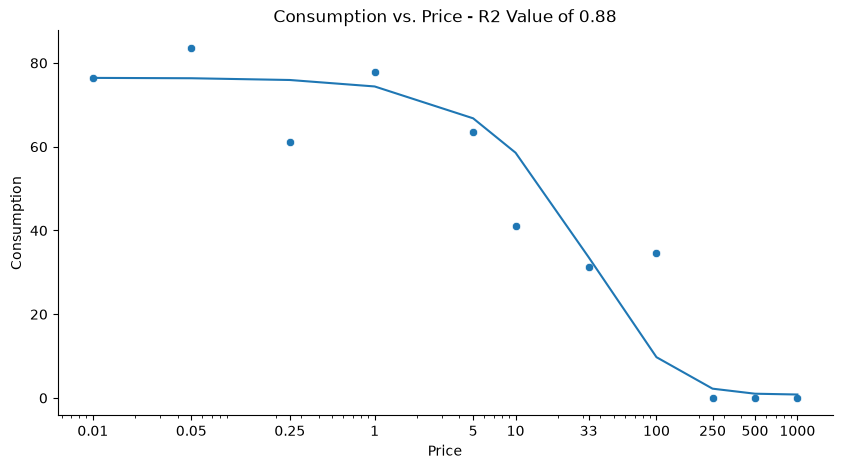

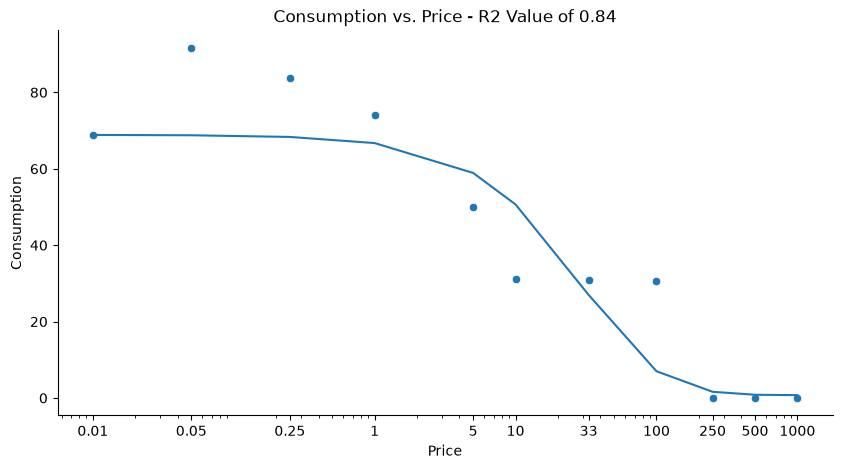

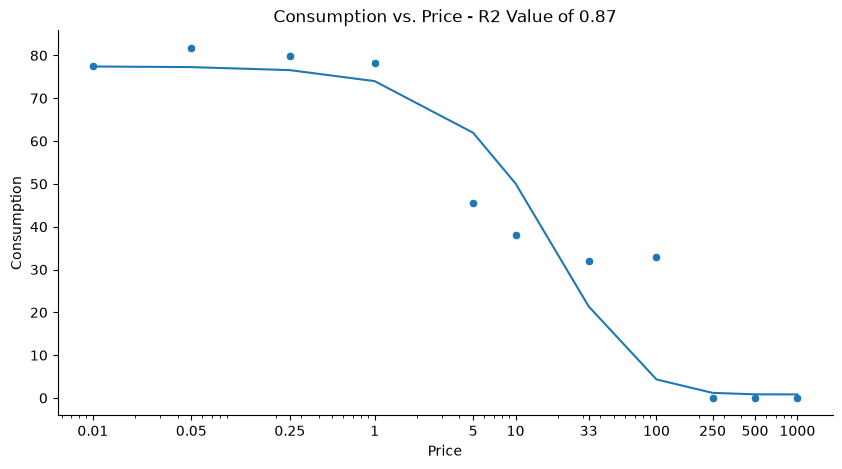

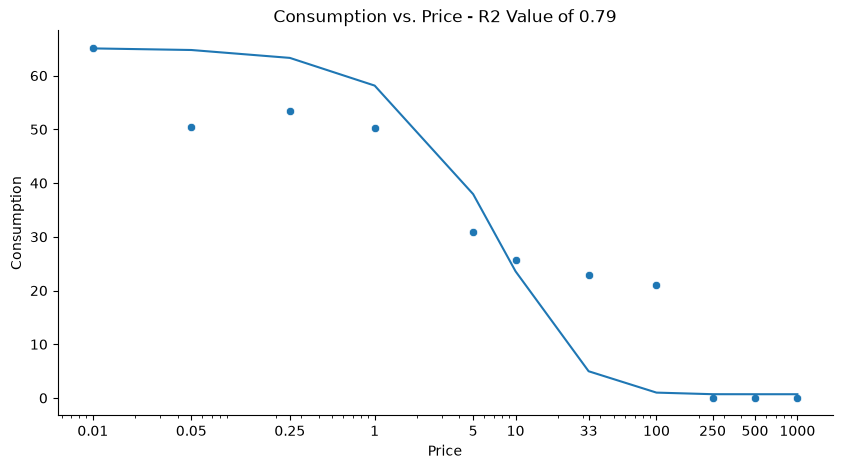

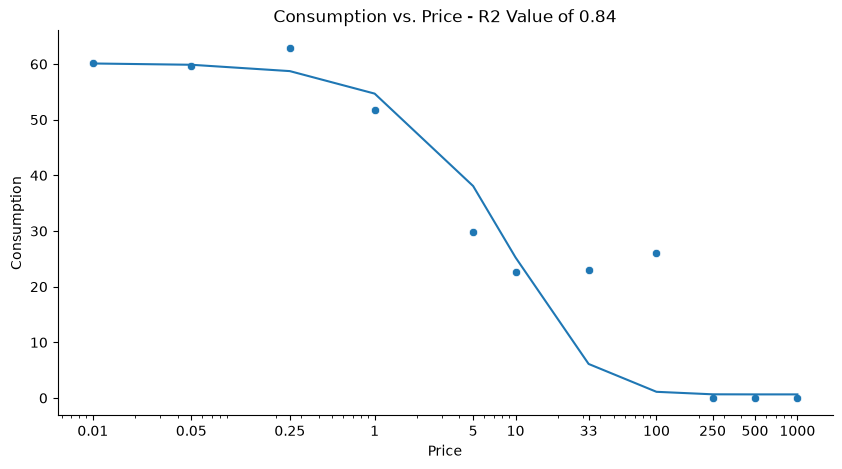

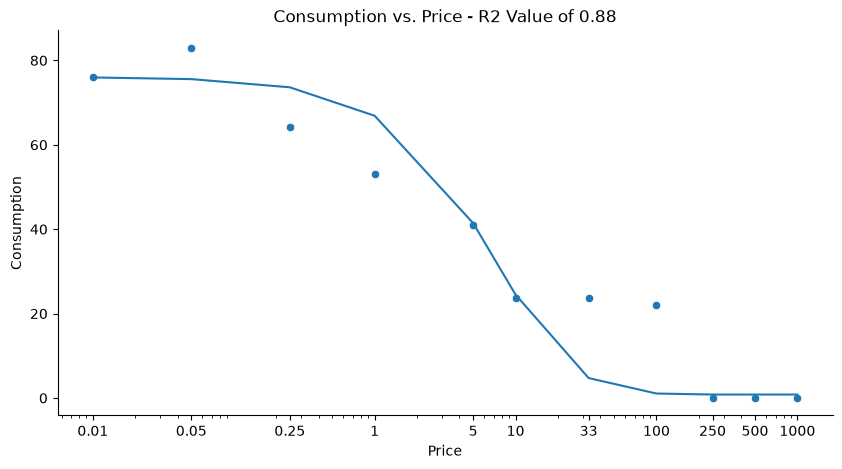

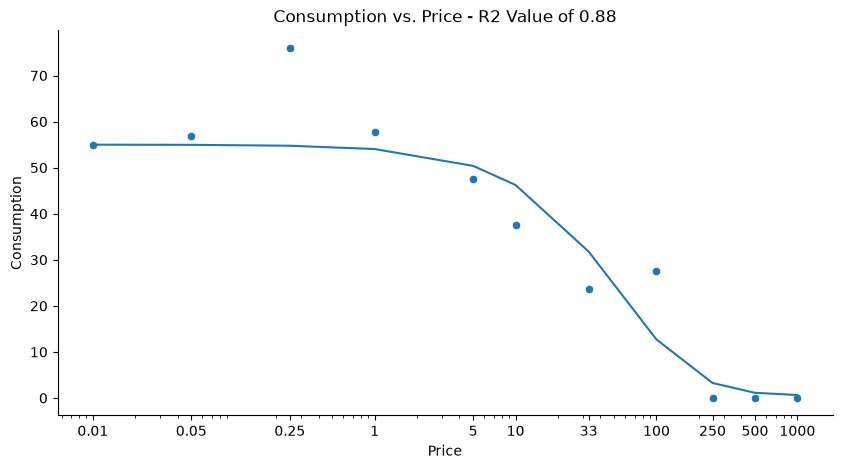

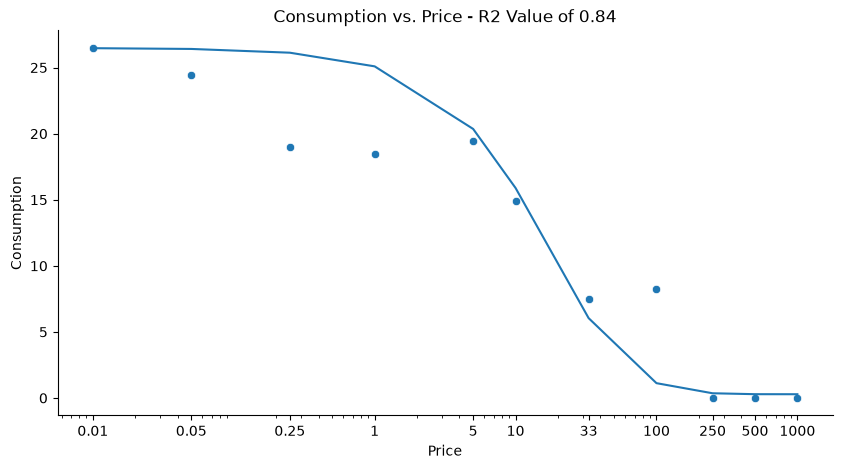

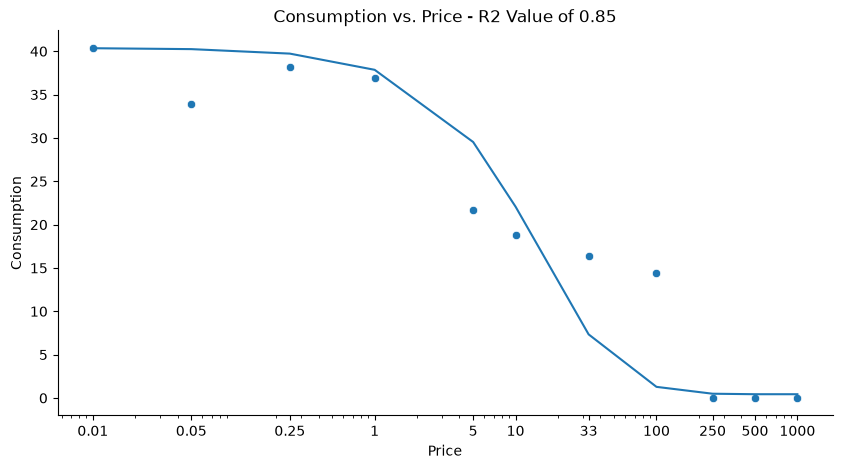

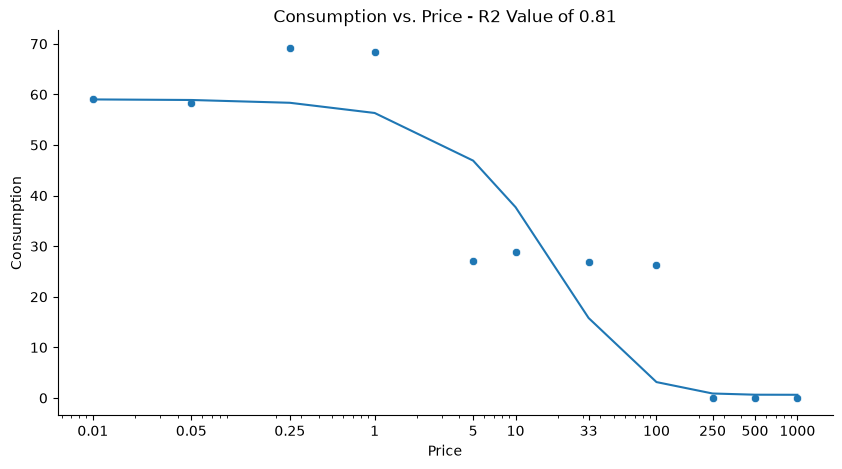

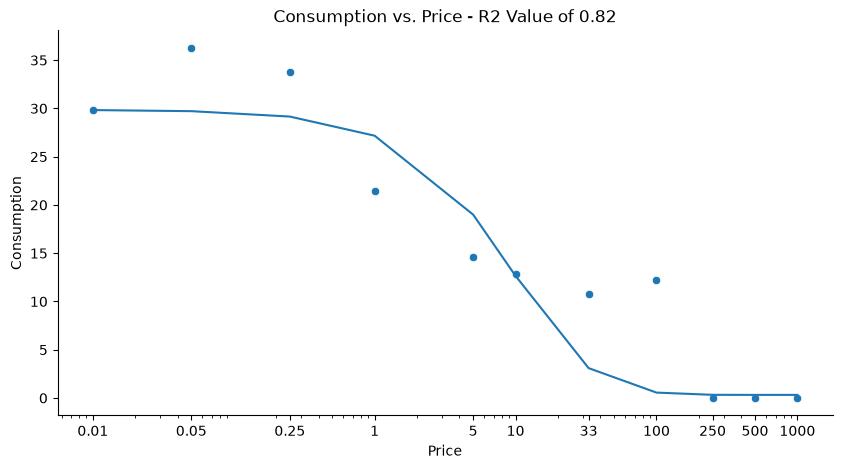

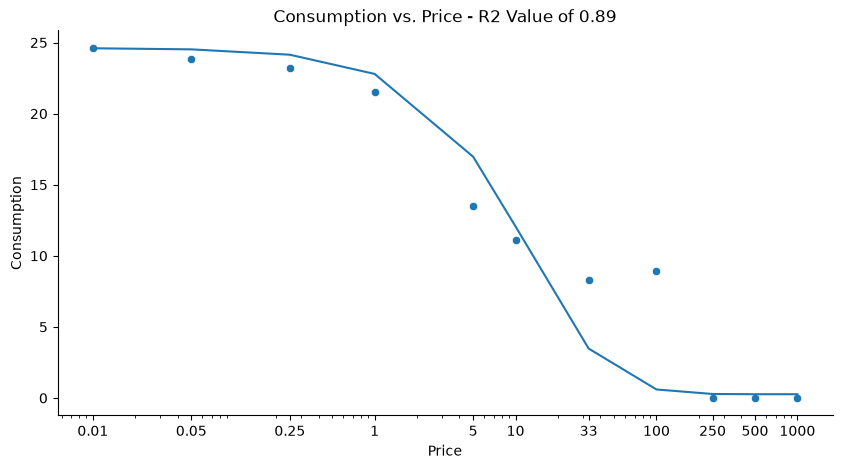

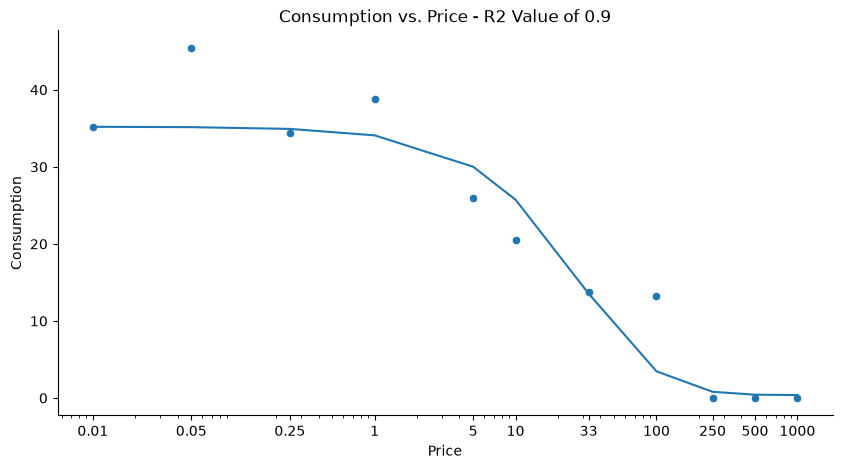

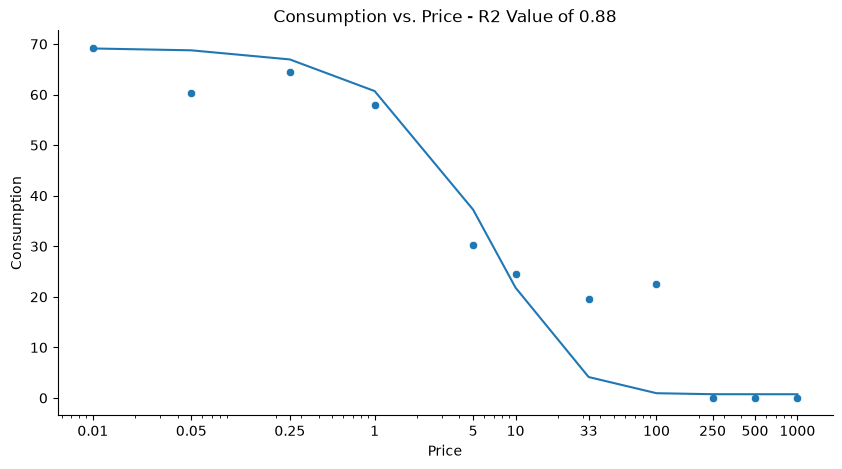

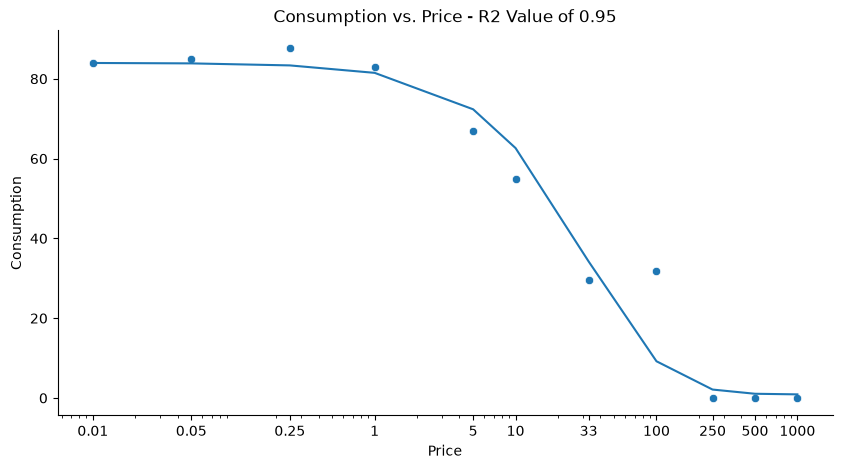

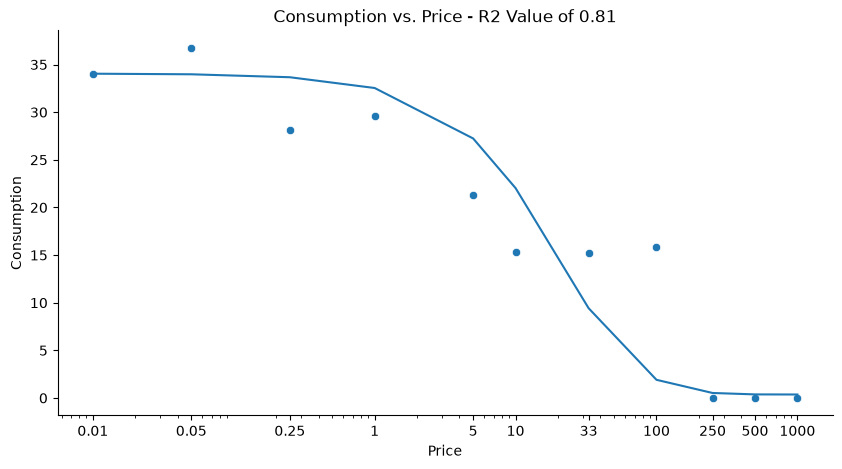

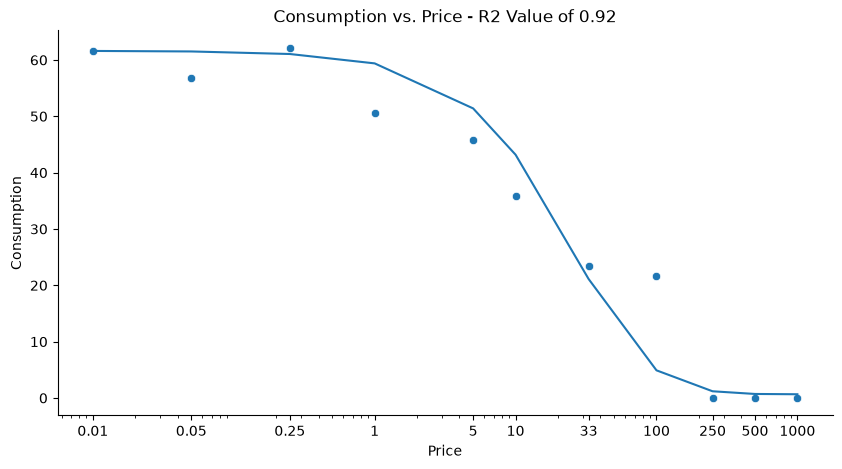

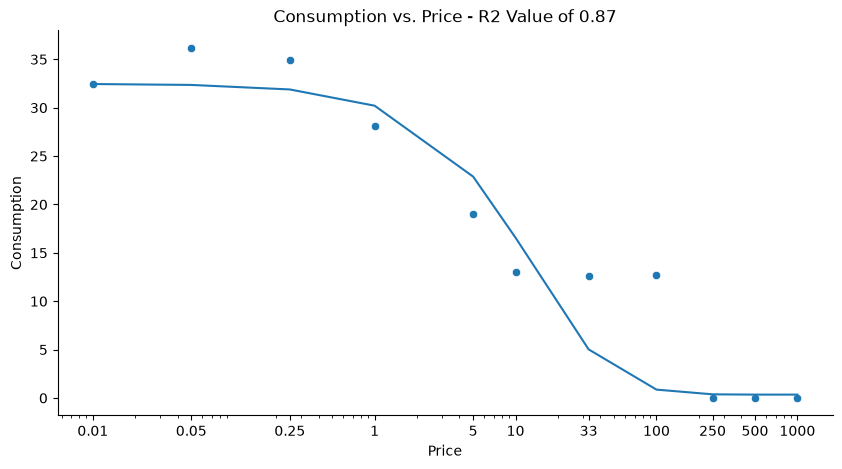

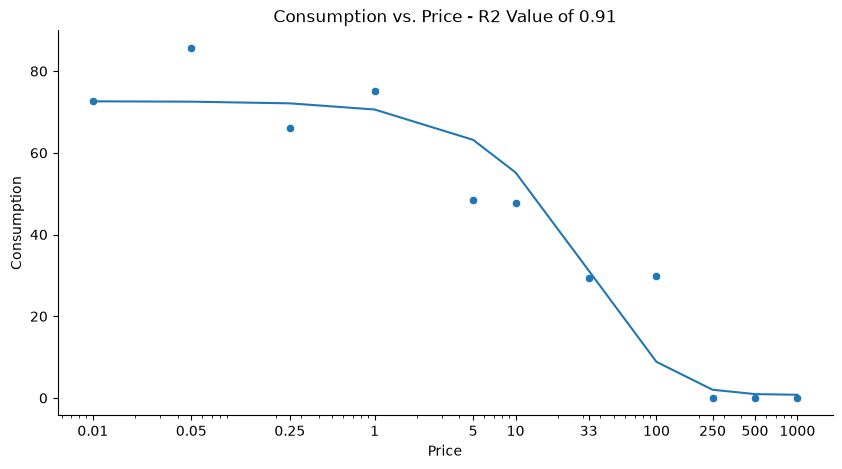

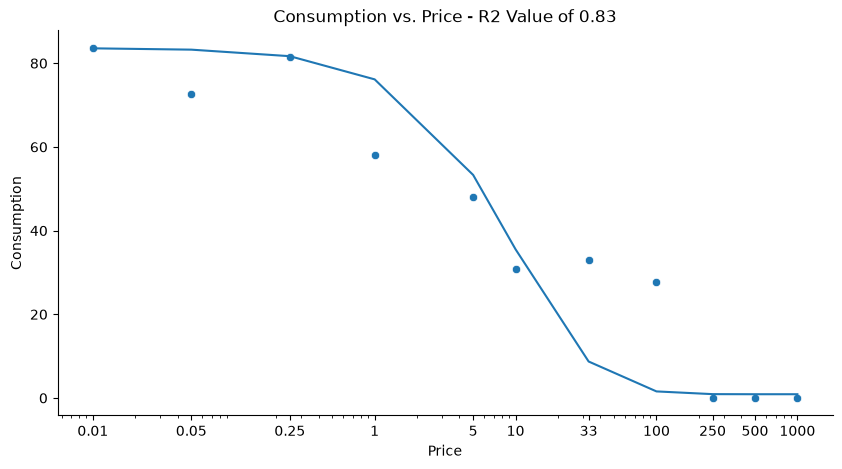

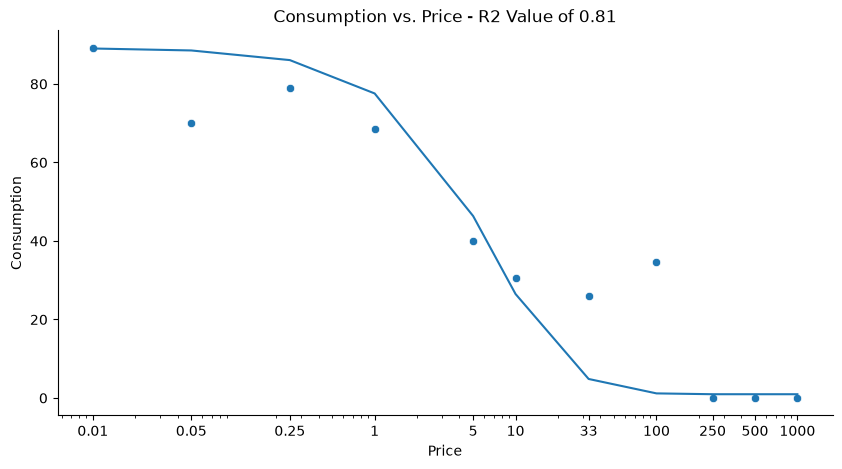

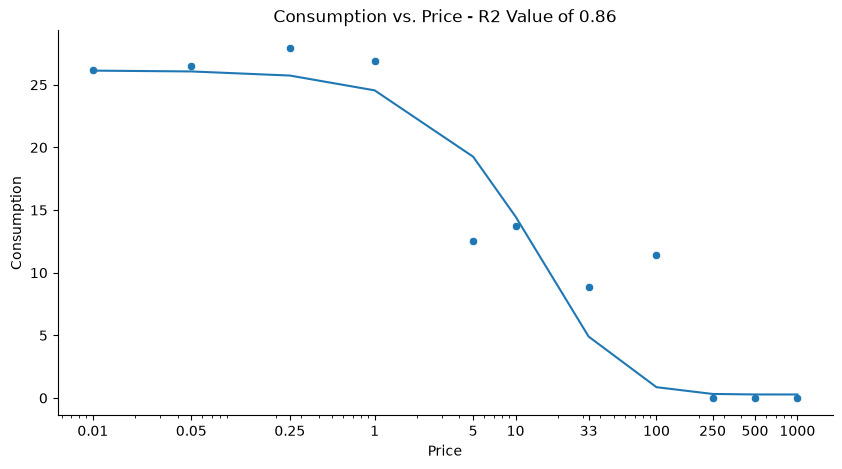

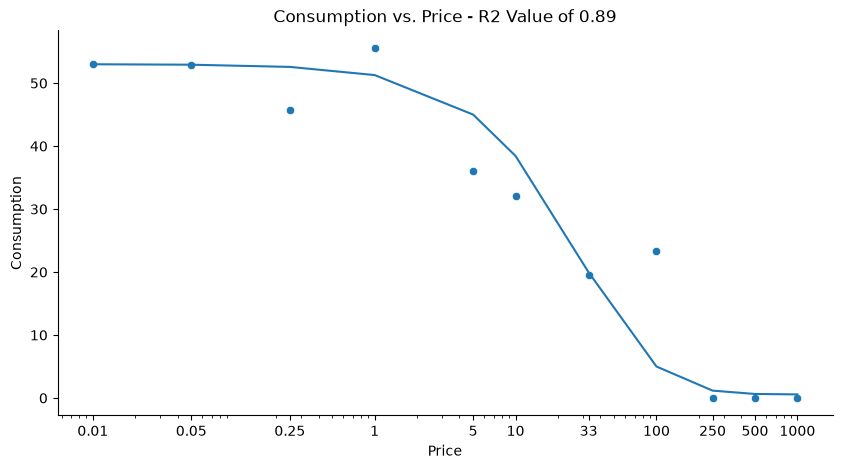

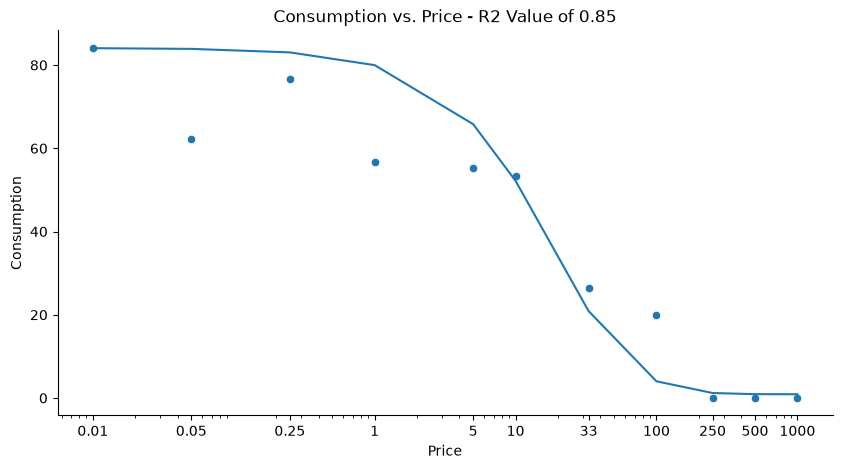

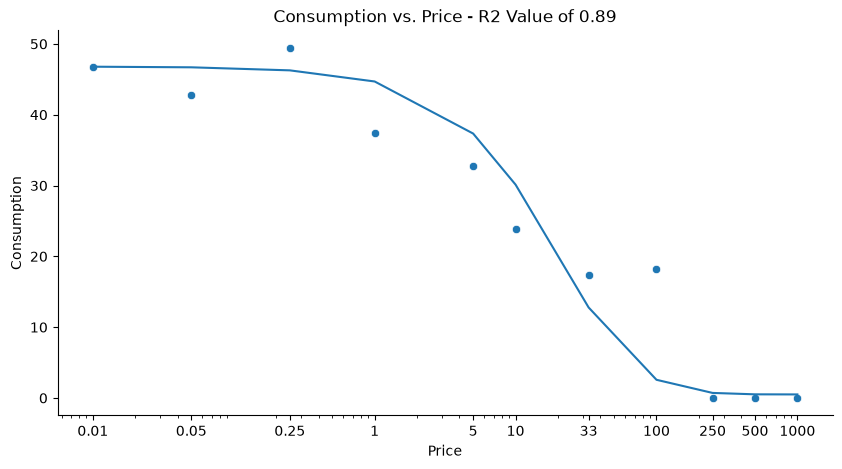

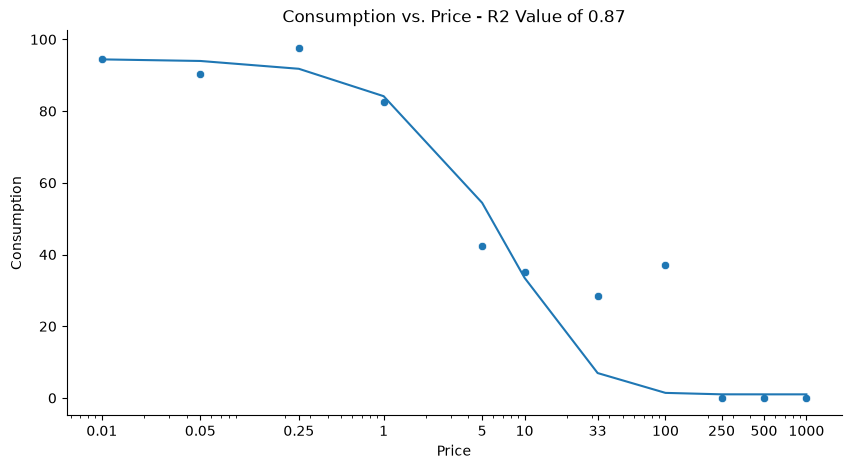

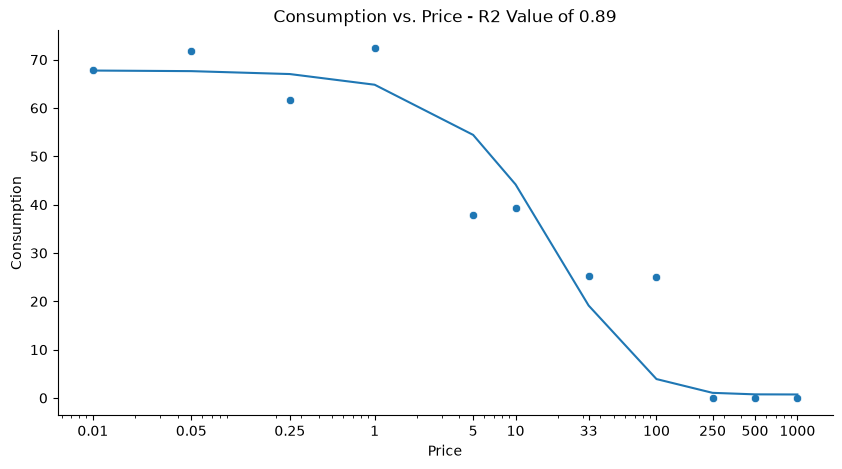

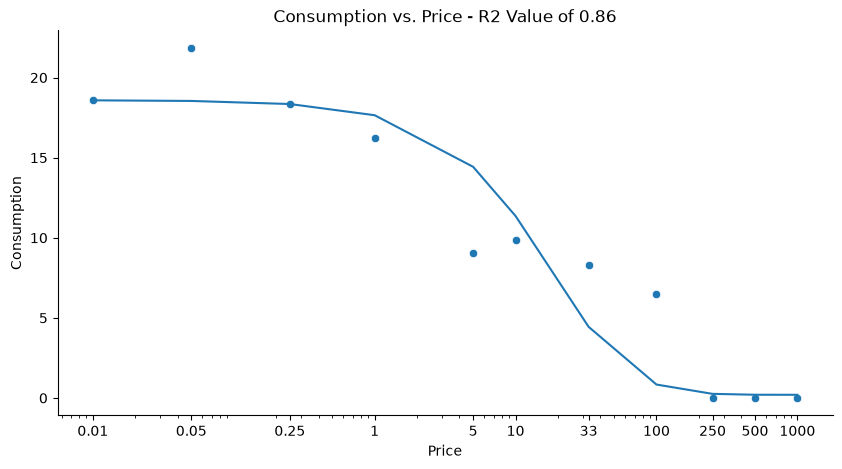

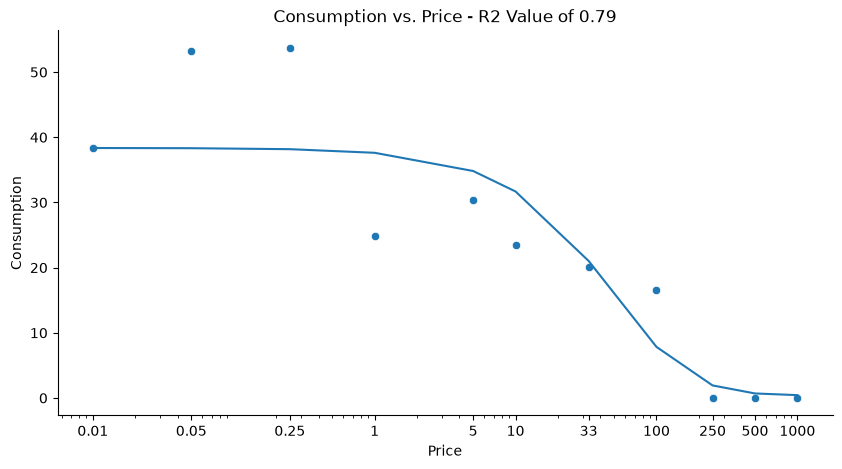

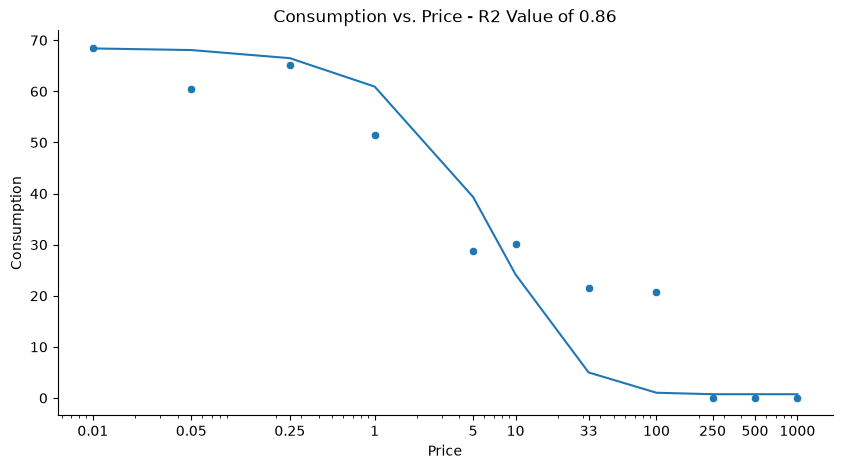

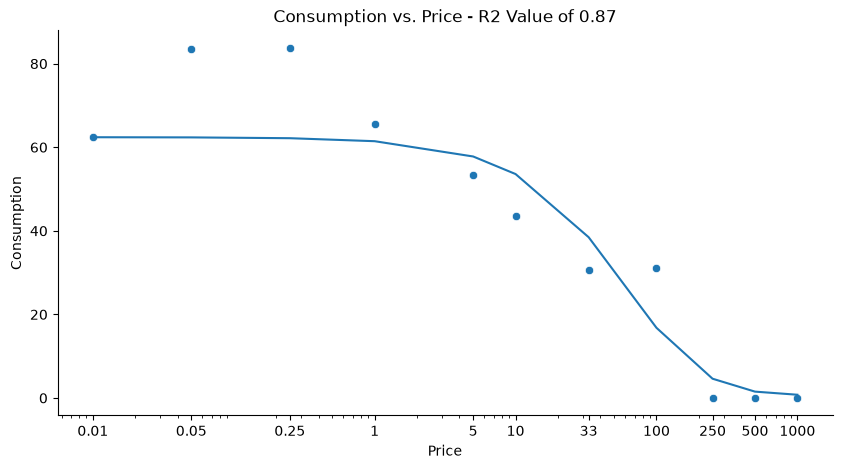

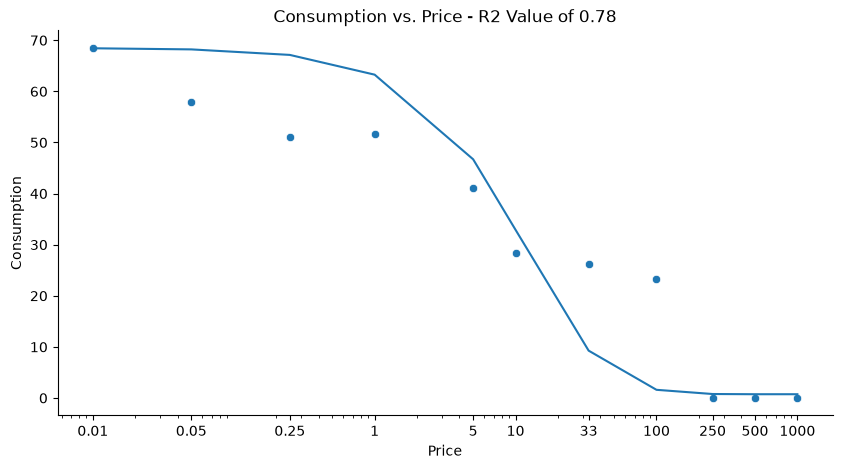

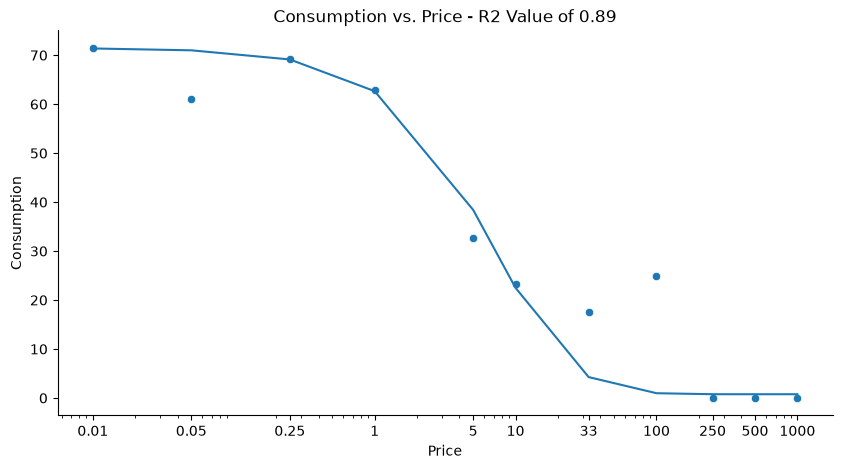

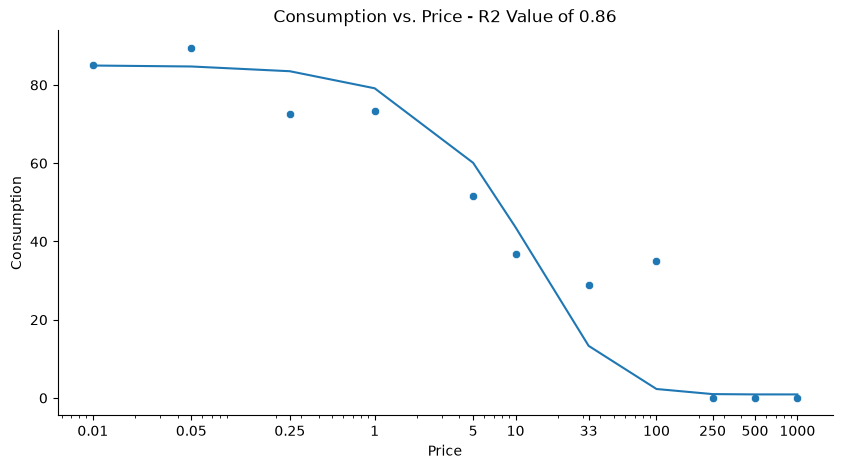

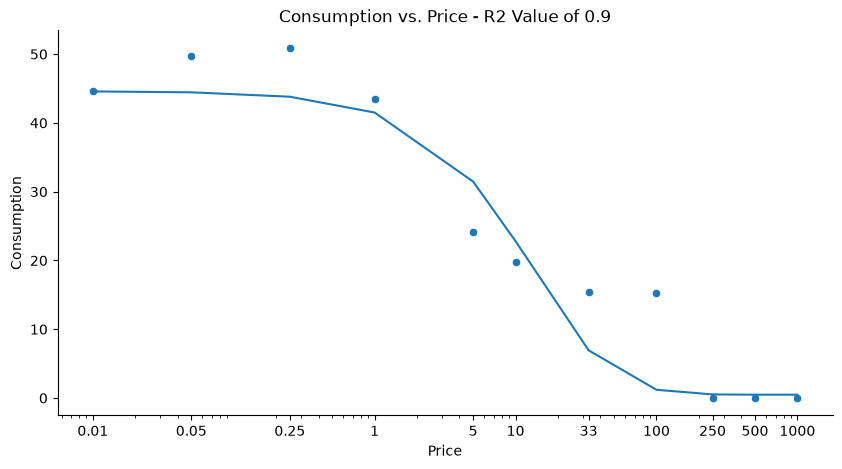

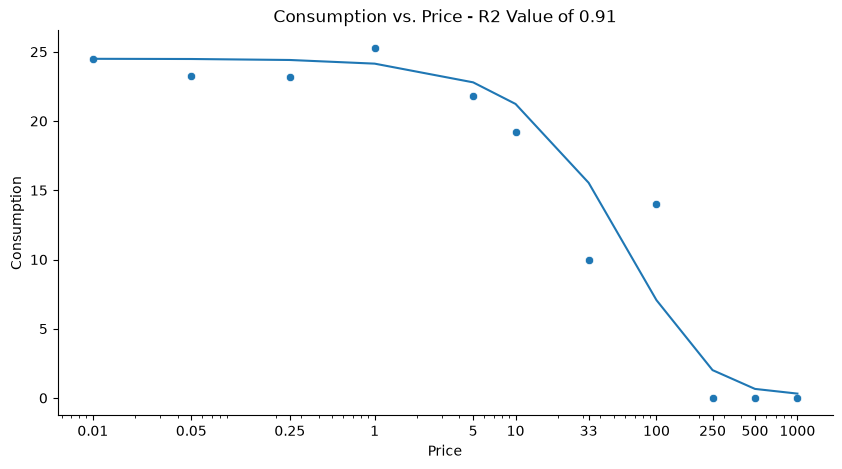

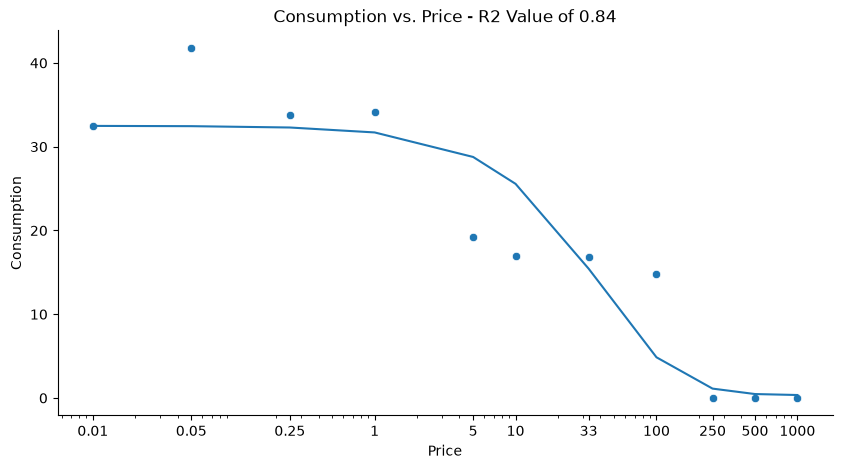

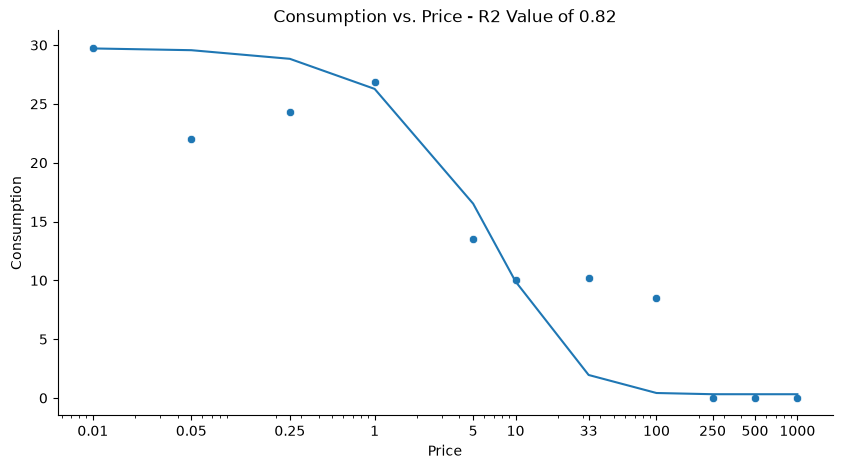

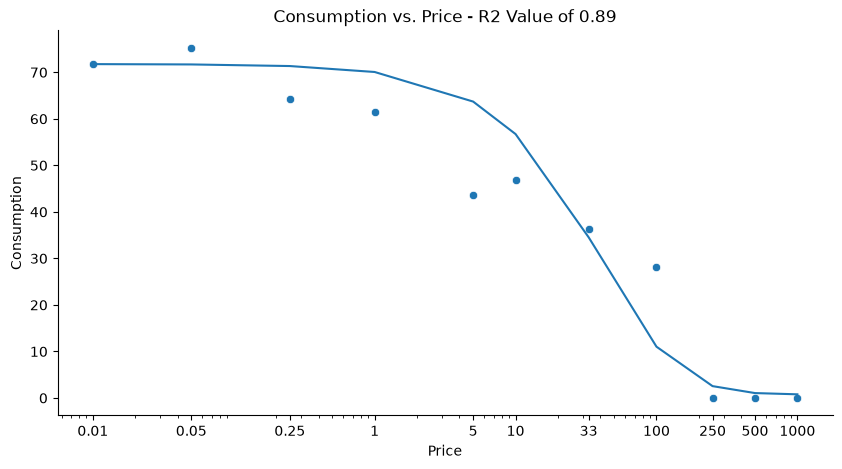

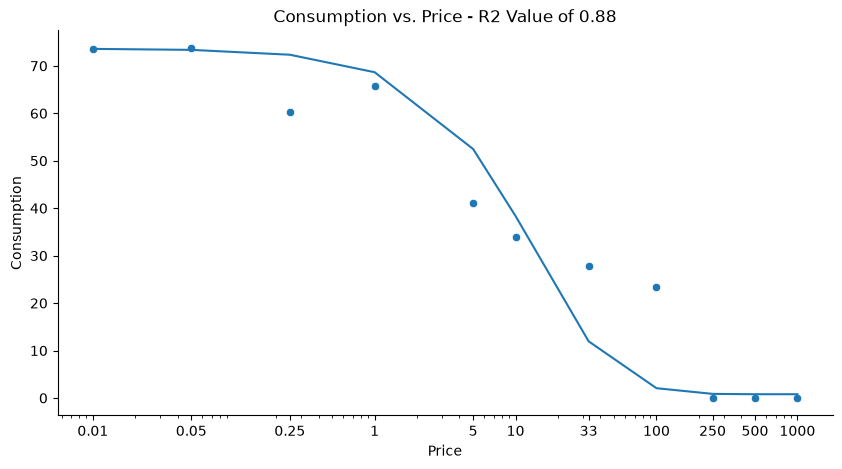

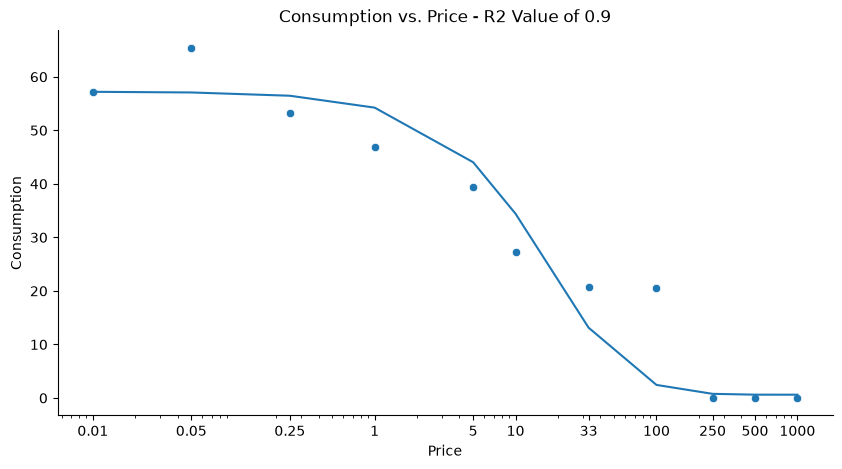

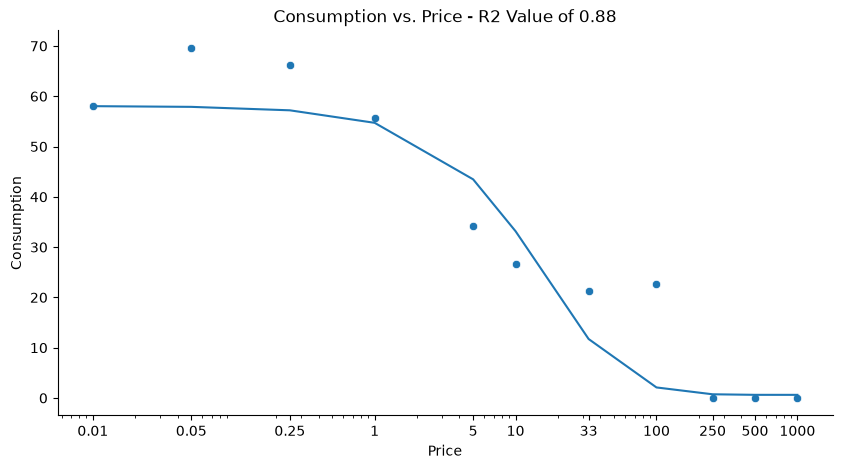

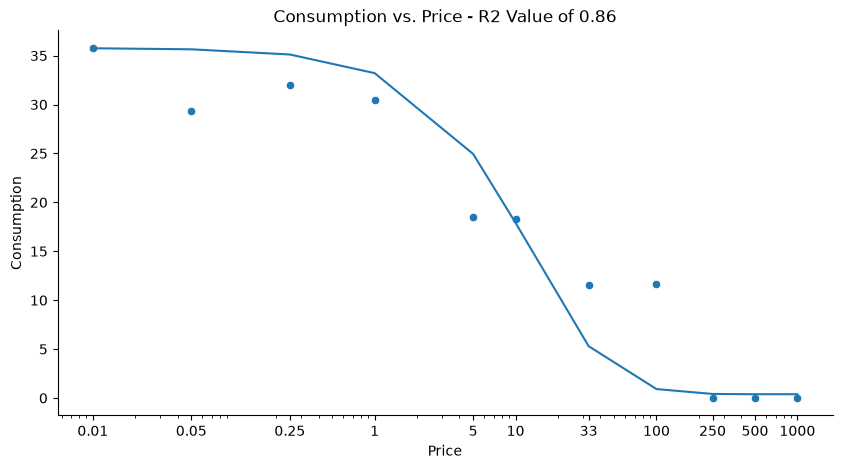

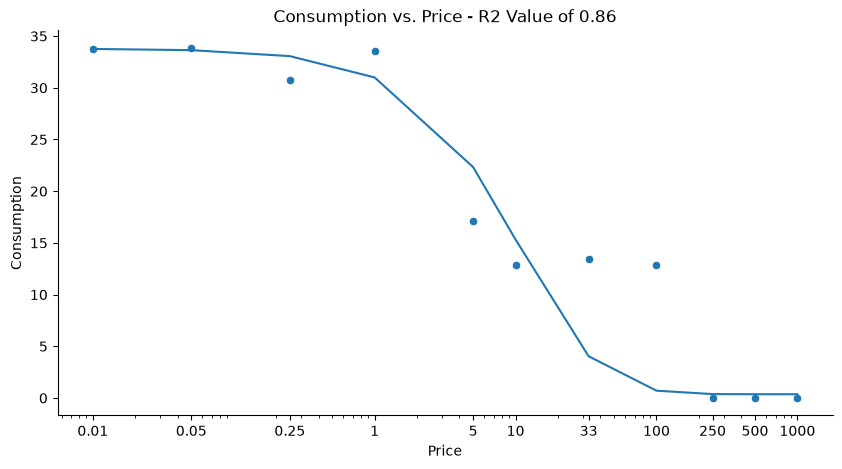

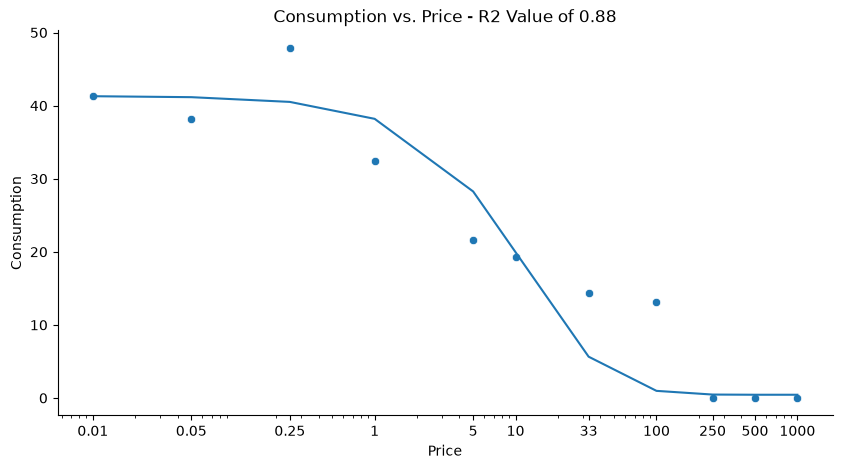

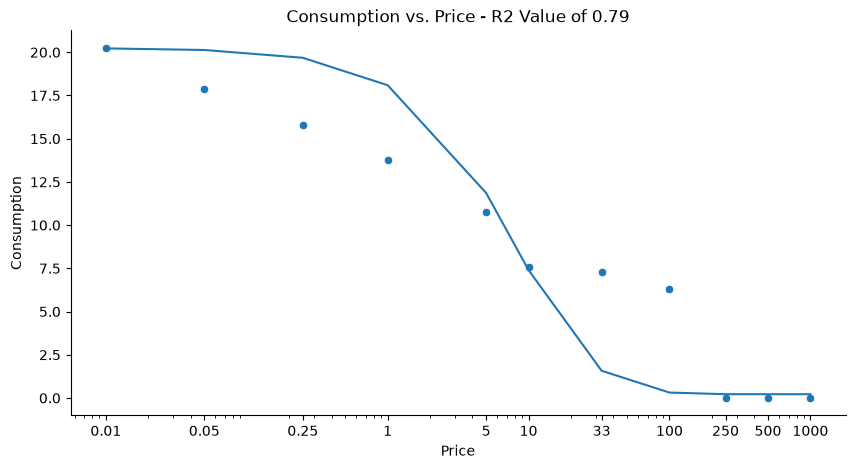

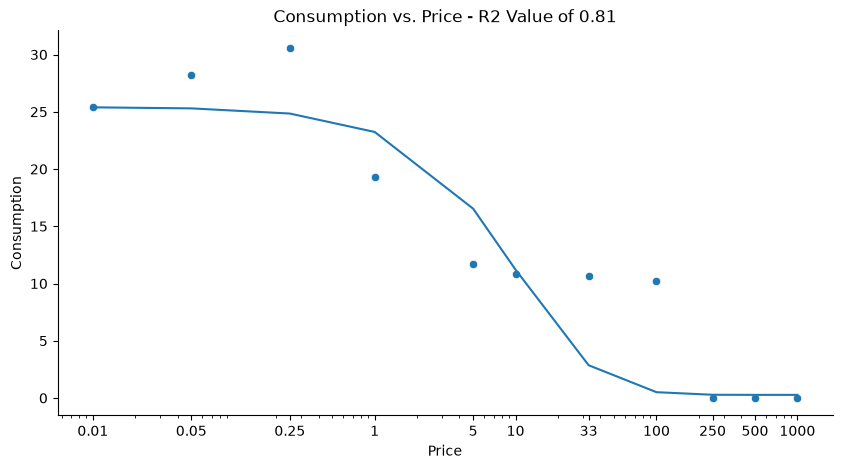

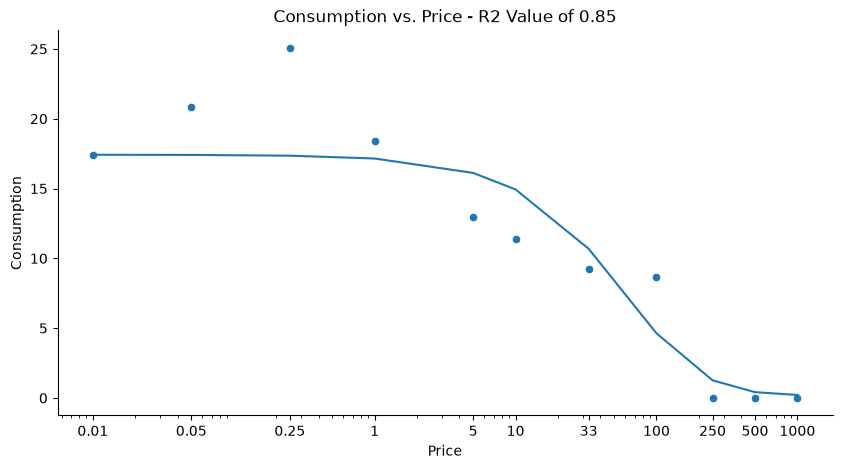

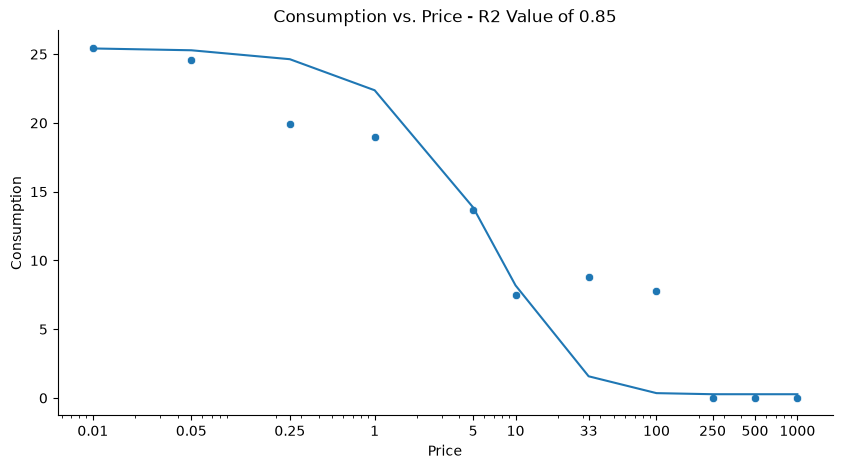

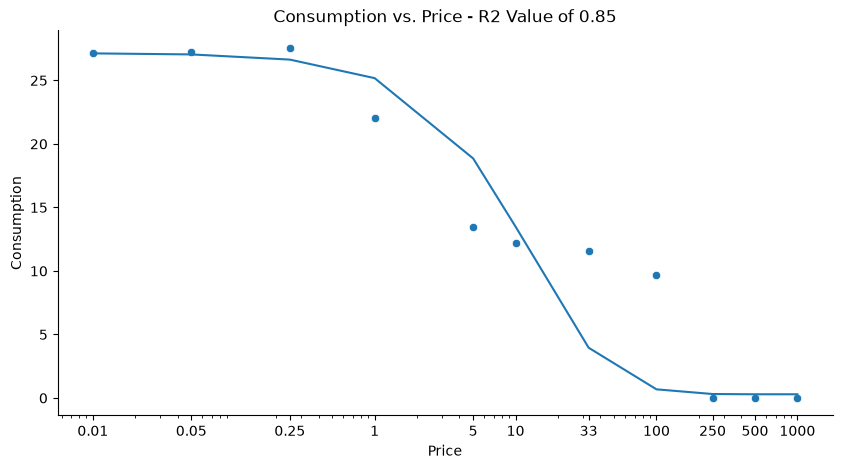

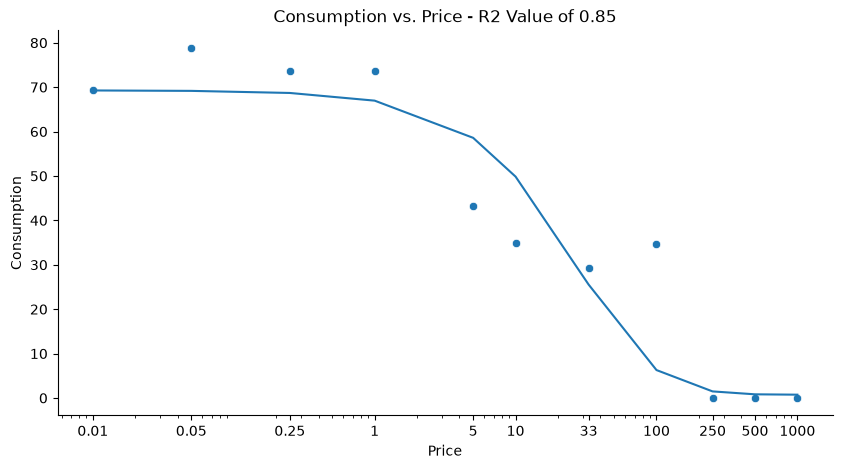

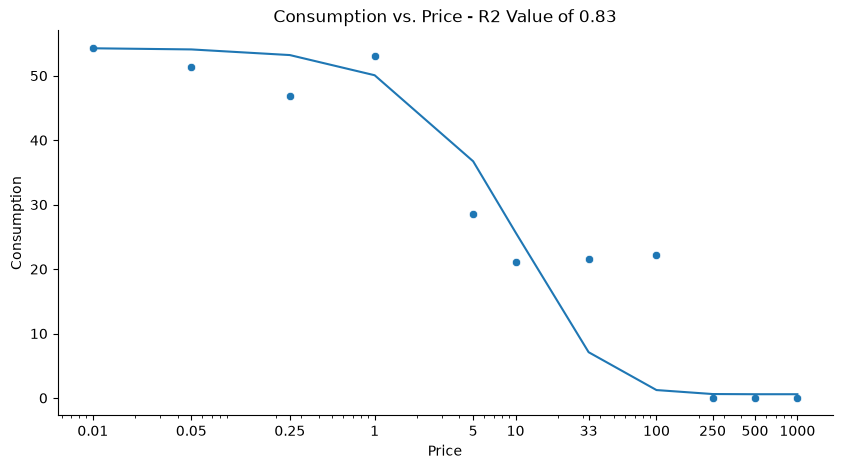

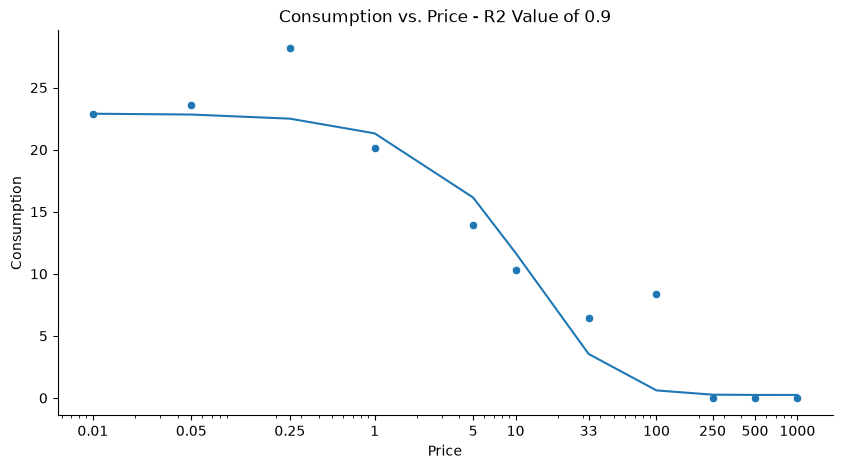

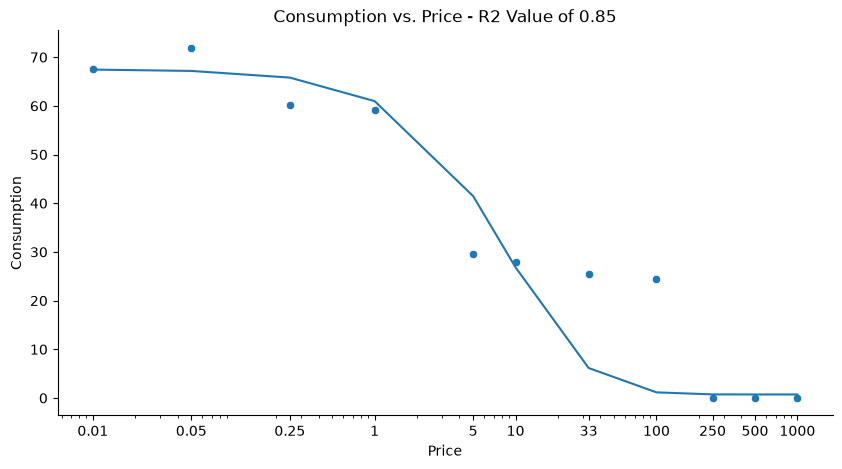

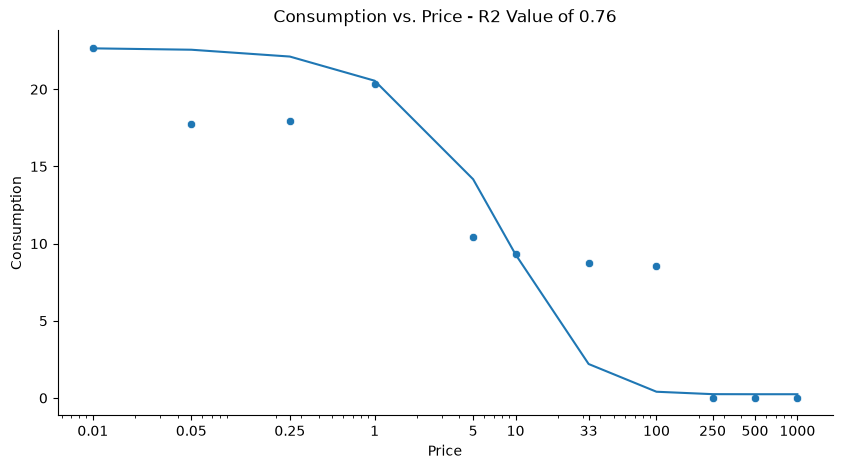

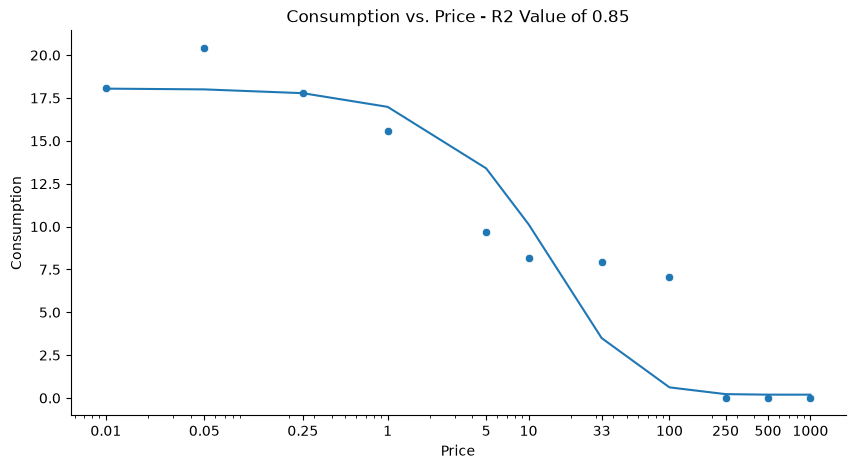

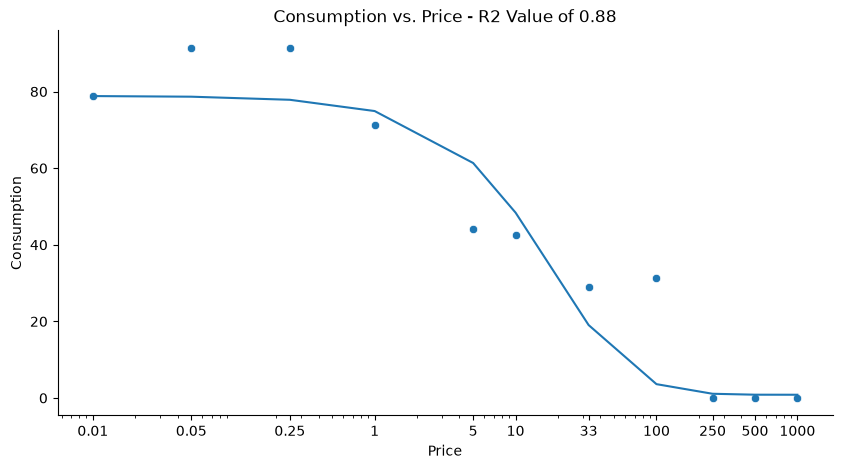

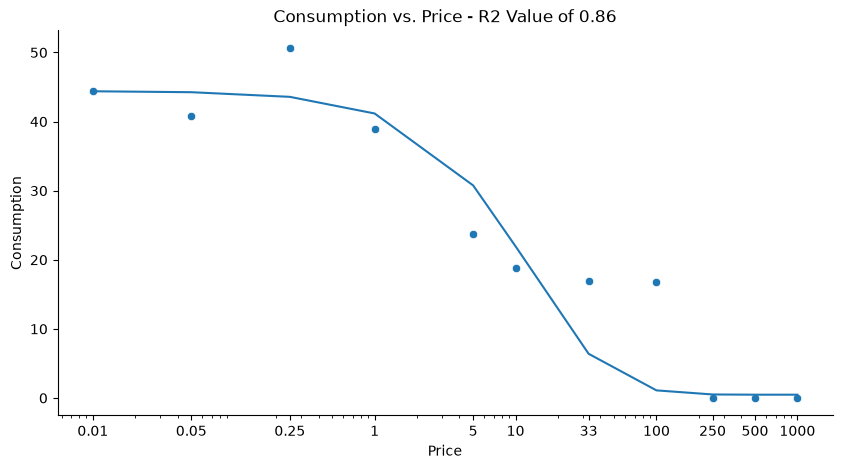

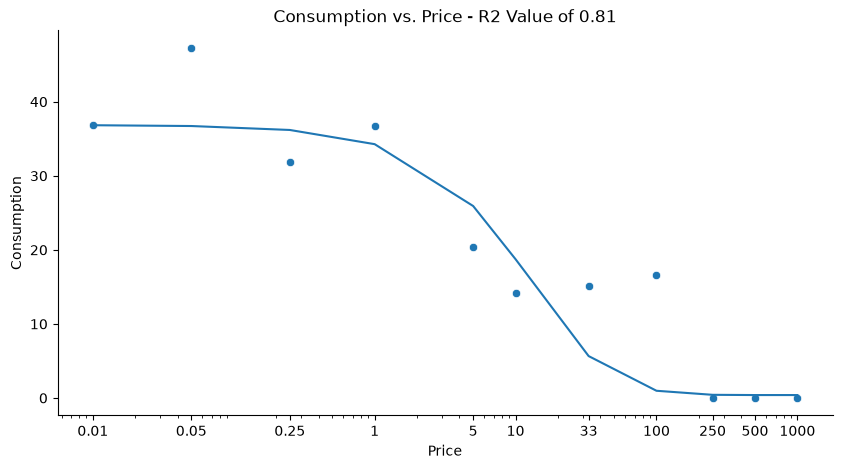

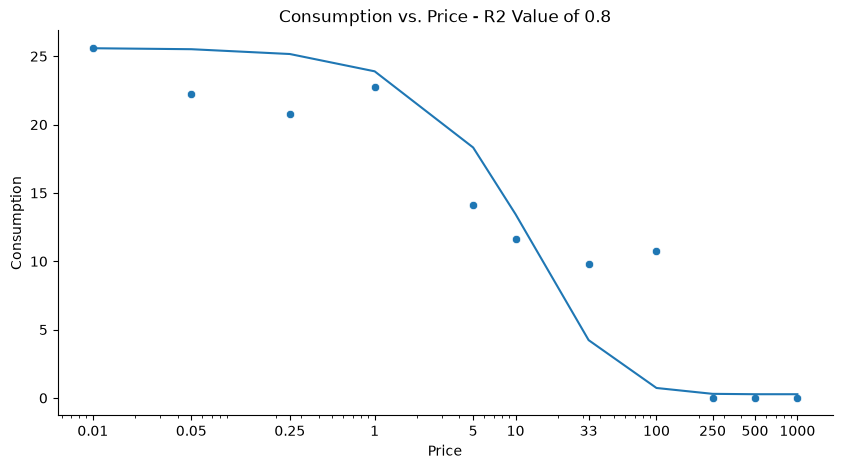

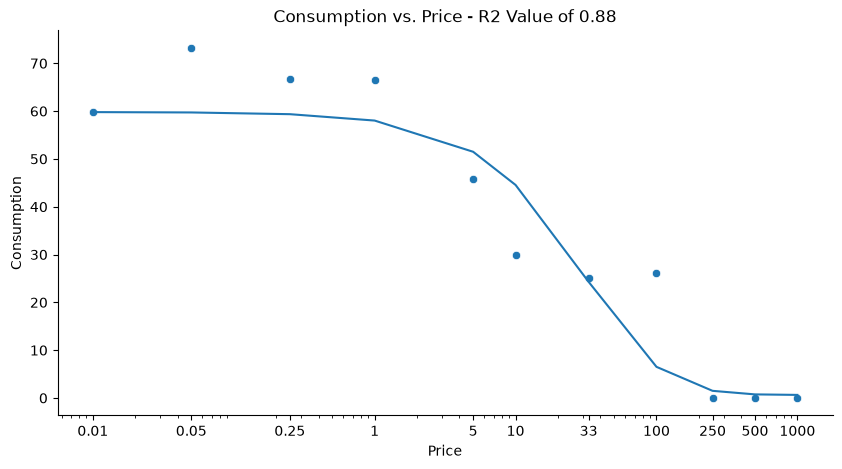

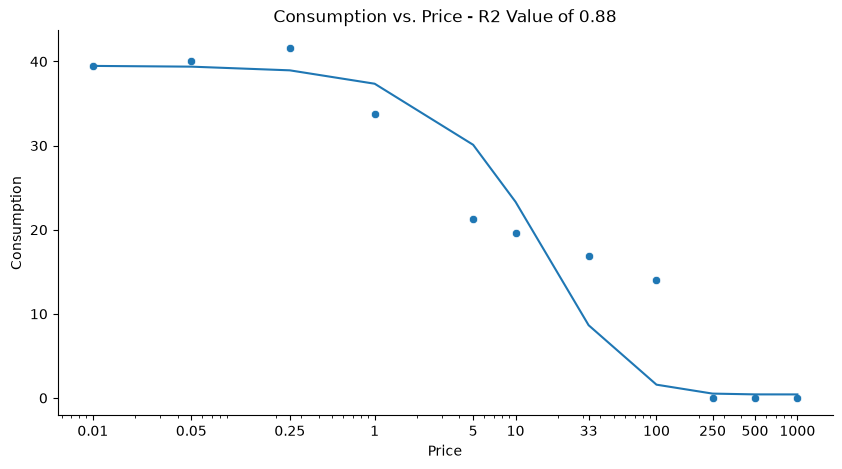

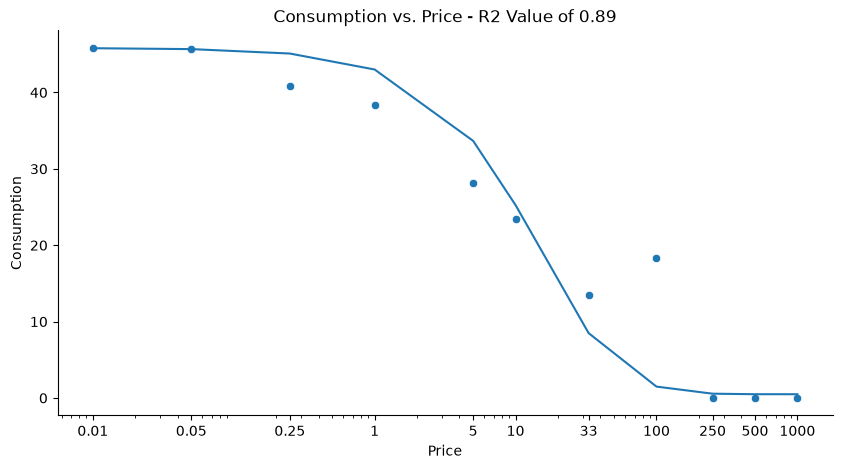

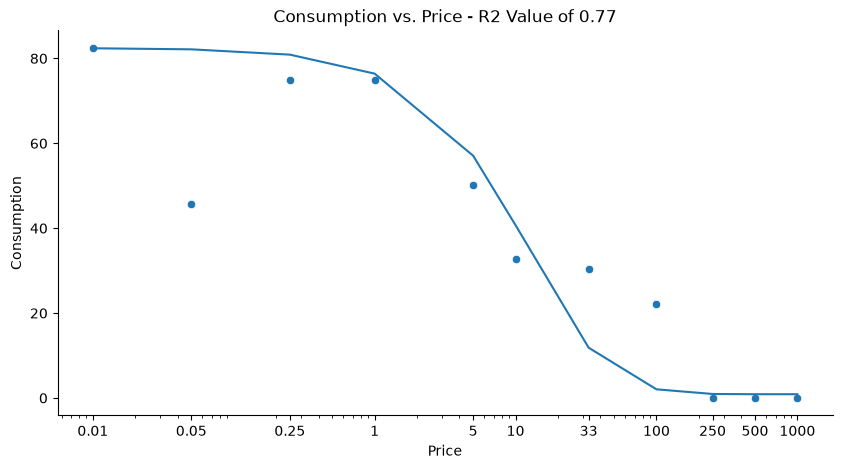

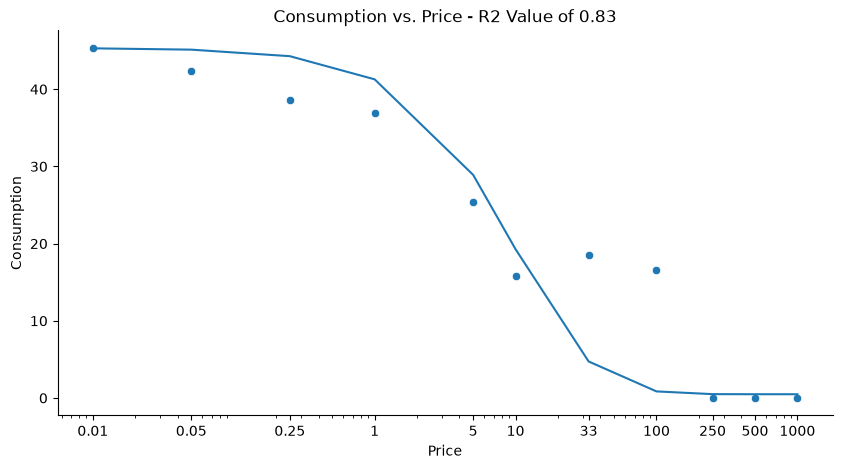

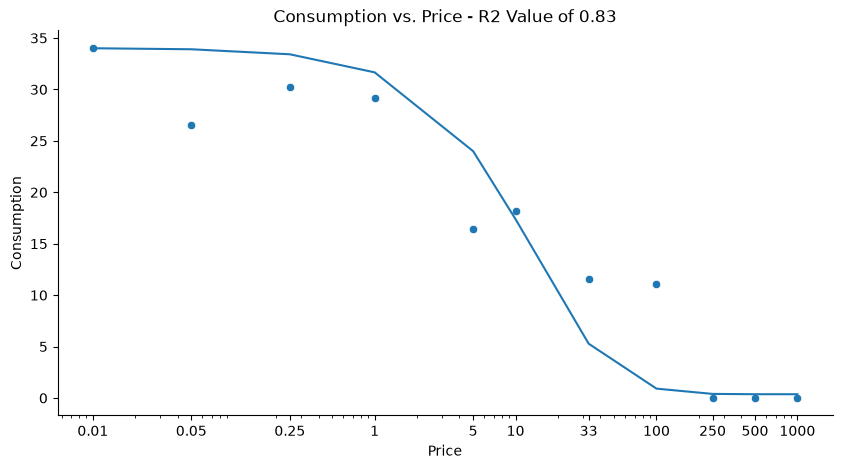

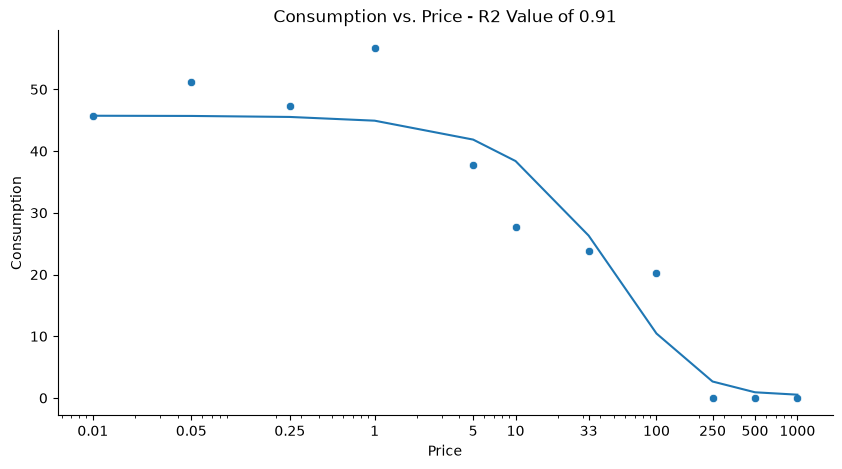

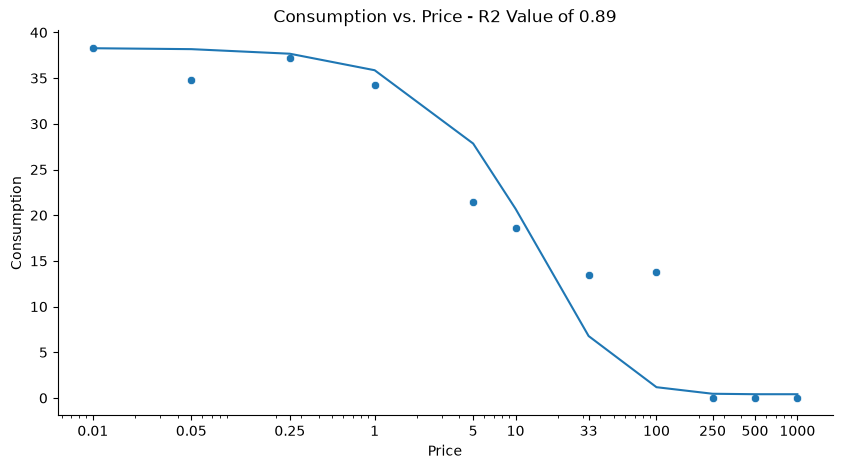

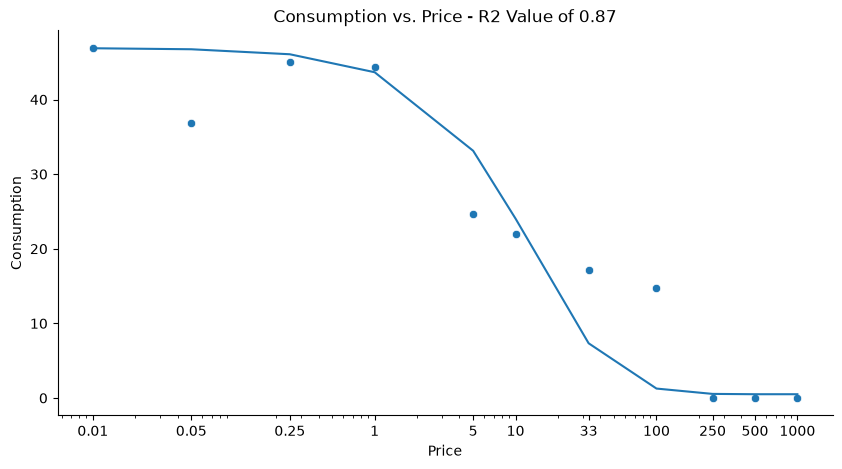

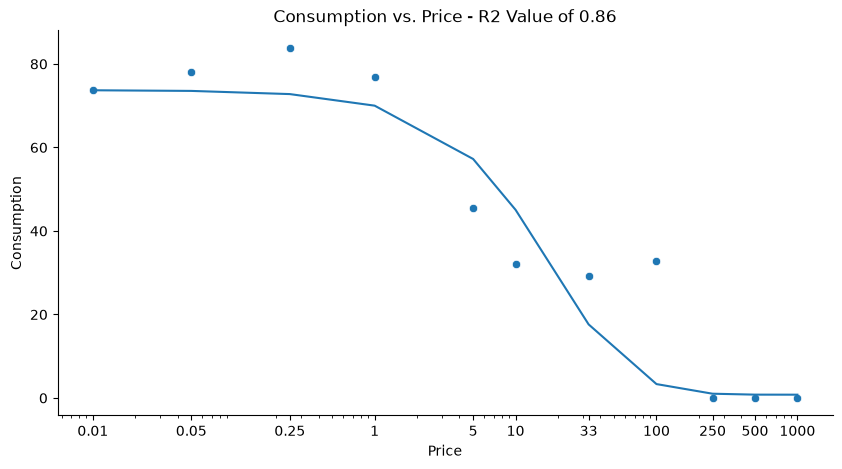

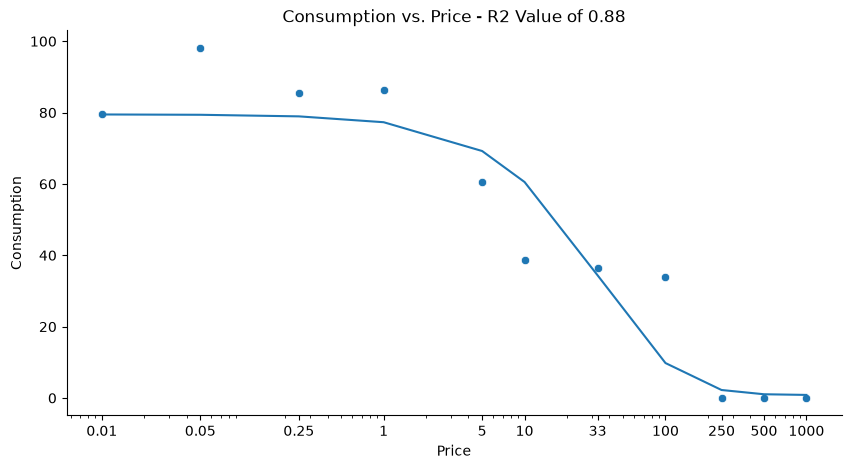

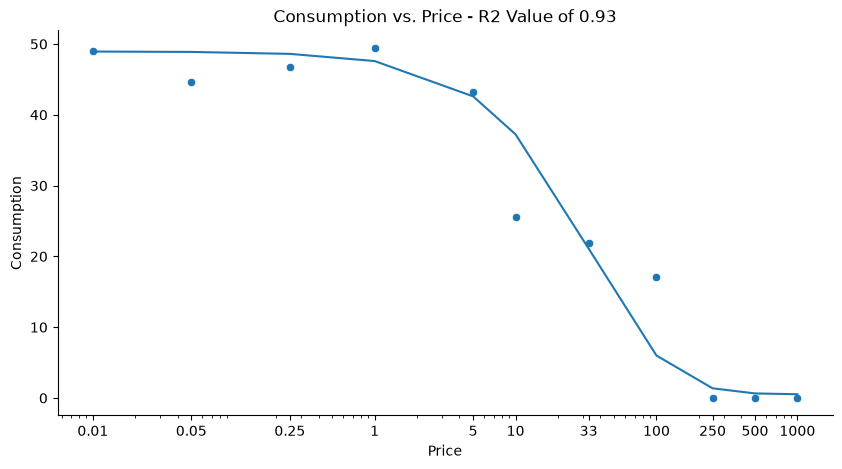

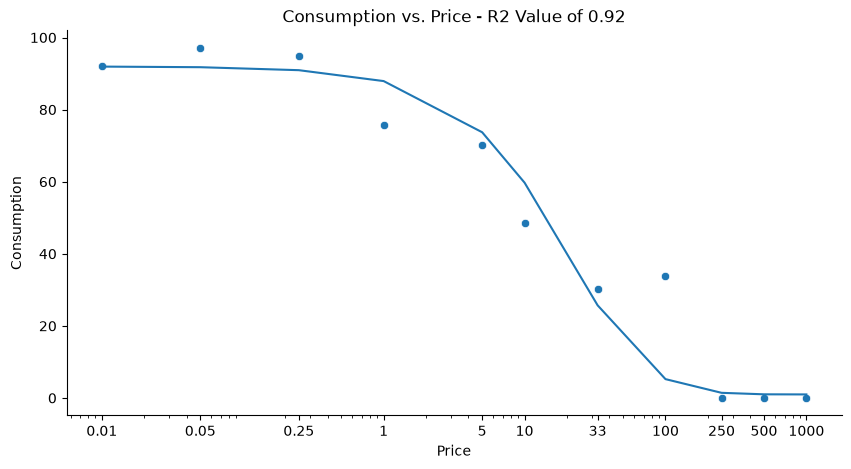

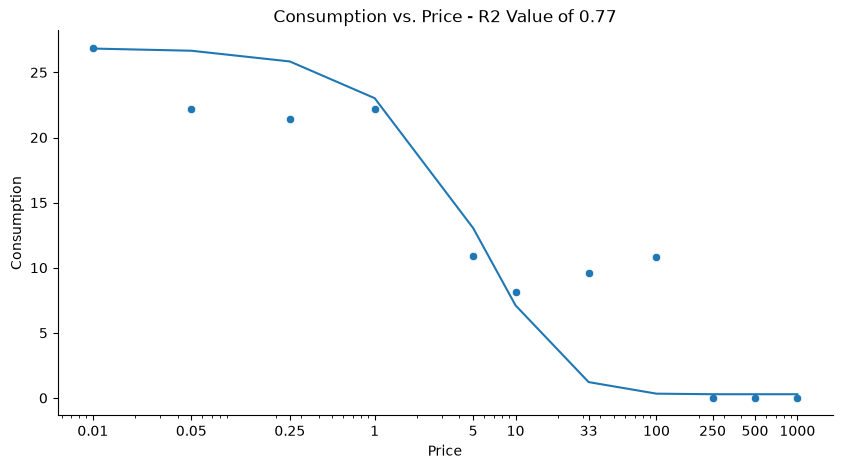

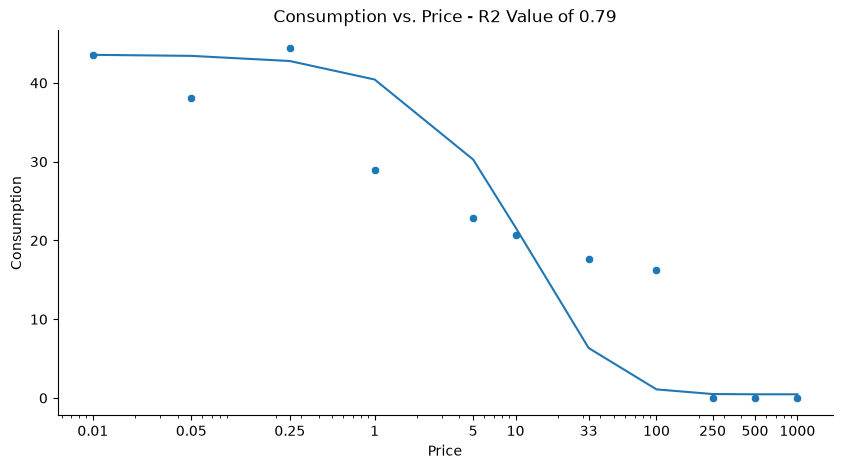

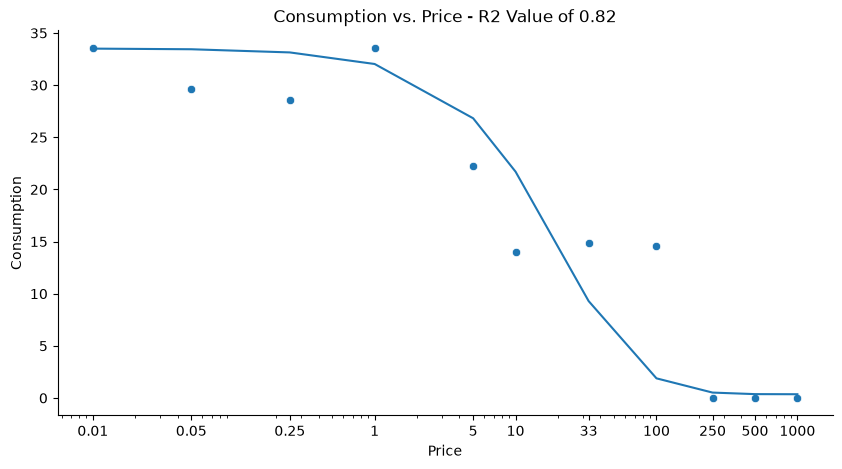

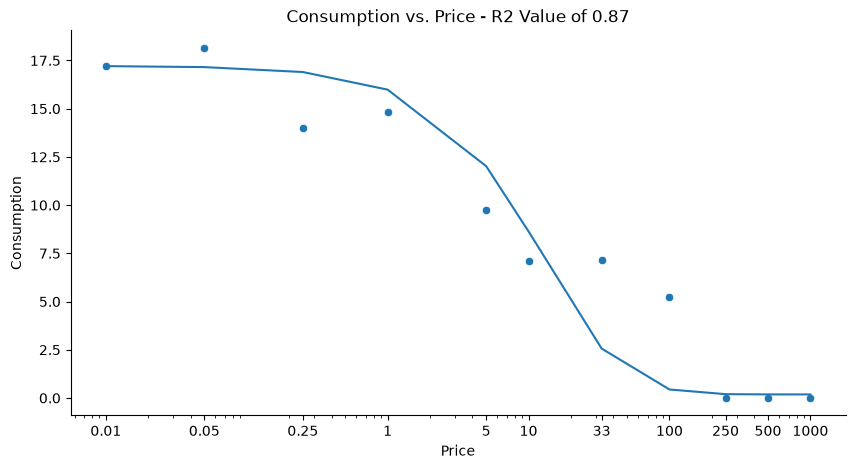

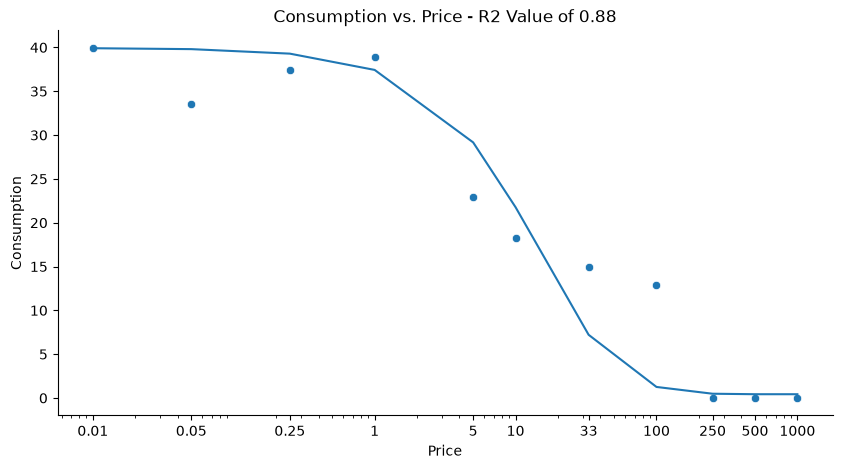

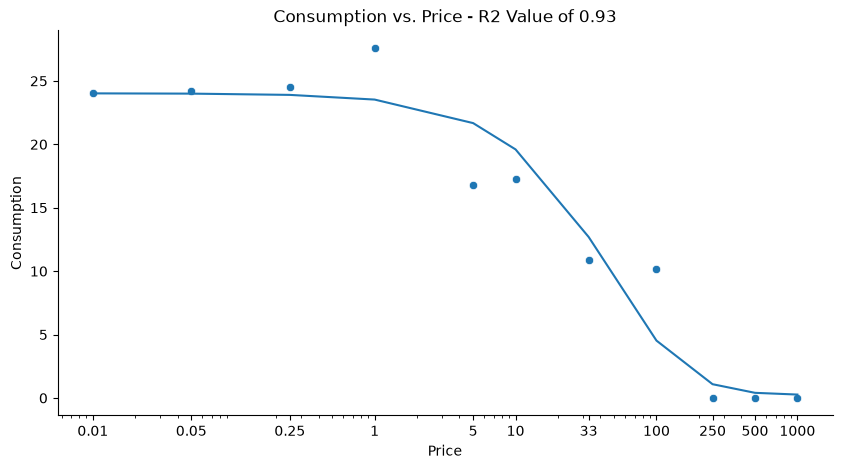

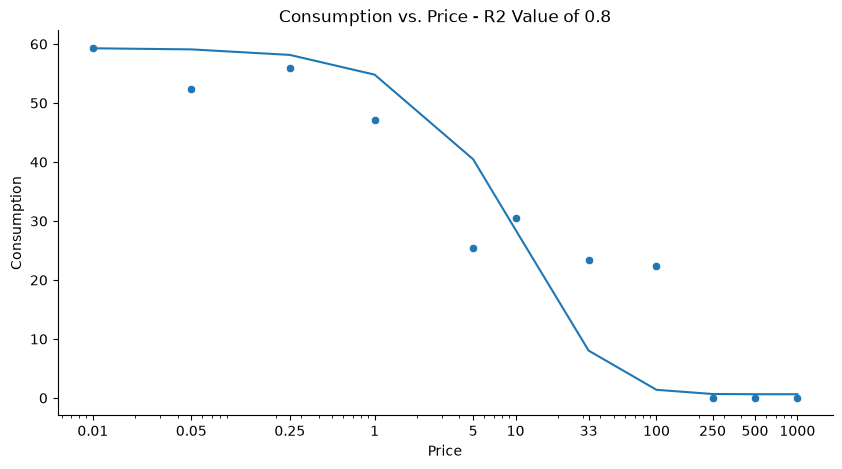

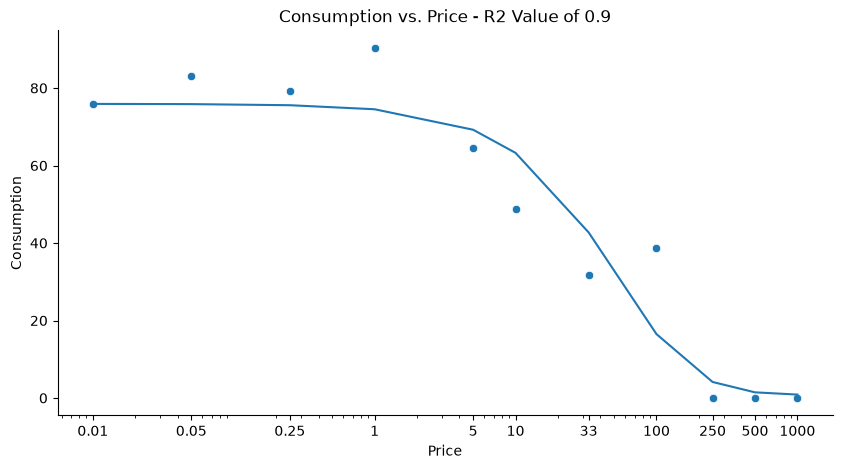

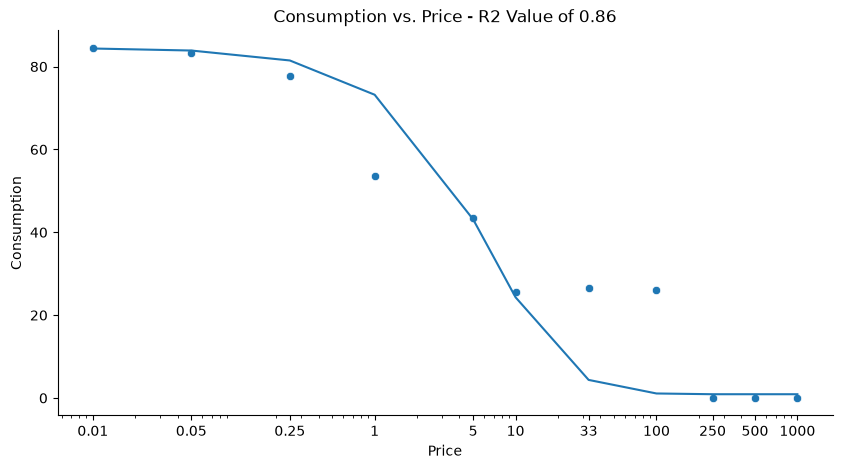

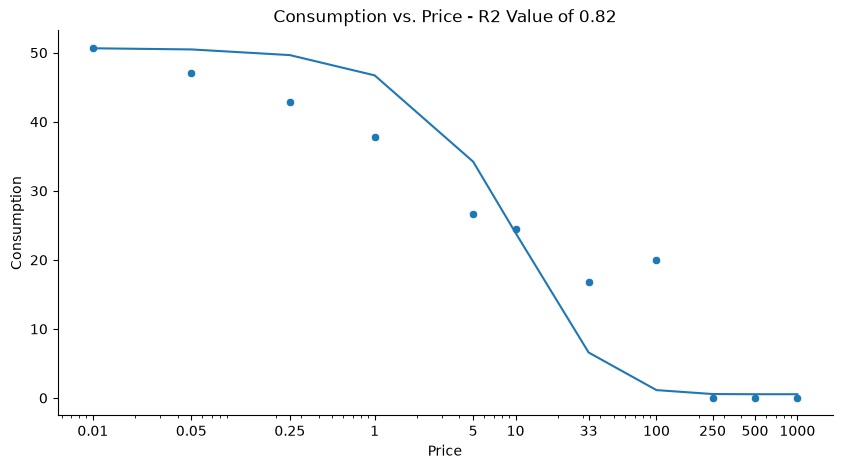

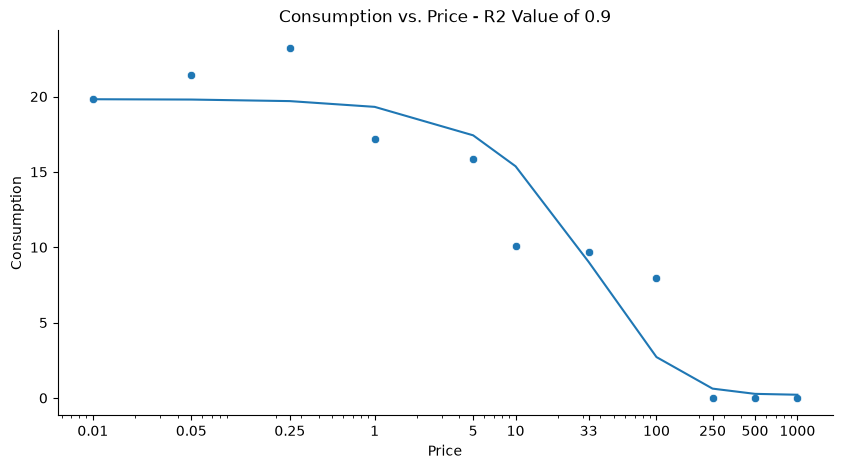

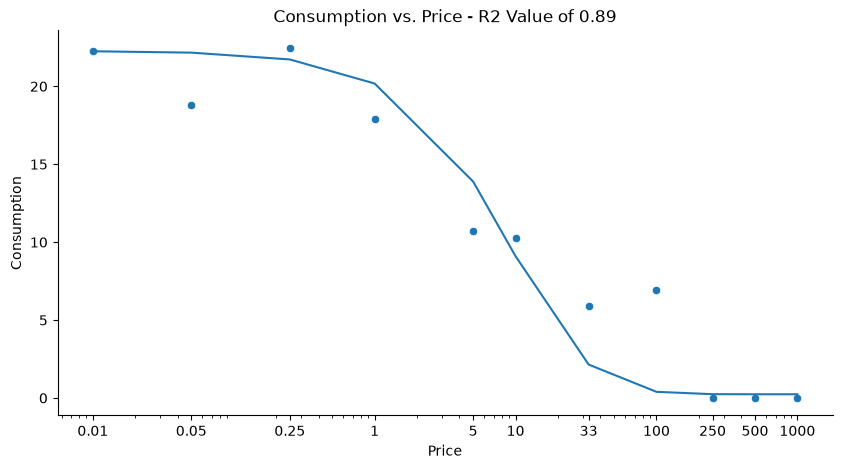

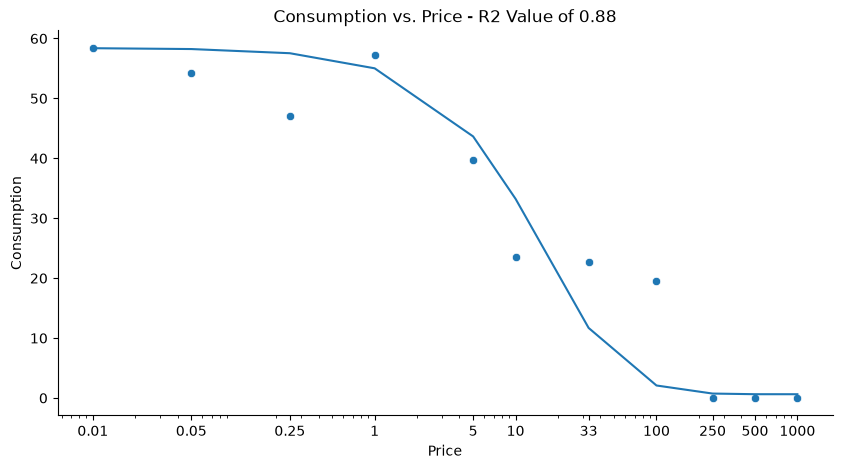


Mean R2: 0.857  Mean RMSE: 7.684


In [10]:
results = []
for participant in df['participant_id'].unique():
    _df = df.loc[df['participant_id'] == participant, :].copy()
    pr = results_df[results_df['participant_id'] == participant].iloc[0]
    alpha_est, Q0_est, k_used = pr['alpha_estimated'], pr['Q0_estimated'], pr['k_used']

    logQ_pred = np.log(Q0_est) + k_used * (np.exp(-alpha_est * _df['price']) - 1)
    _df['predicted_consumption'] = np.exp(logQ_pred)

    y_obs, y_pred = _df[['value', 'predicted_consumption']].values.T
    r2 = round(r2_score(y_obs, y_pred), 2)
    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
    results.append({"participant": participant, "r2_value": r2, "rmse": rmse,
                    "alpha_estimated": alpha_est, "Q0_estimated": Q0_est,
                    "alpha_true": pr['alpha_true'], "Q0_true": pr['Q0_true']})

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(data=_df, x='price', y='value', ax=ax)
    sns.lineplot(data=_df, x='price', y='predicted_consumption', ax=ax)
    sns.despine(top=True, right=True)
    ax.set_xscale('log'); ax.set_xlabel('Price'); ax.set_ylabel('Consumption')
    ticks = [0.01, 0.05, 0.25, 1, 5, 10, 33, 100, 250, 500, 1000]
    ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
    ax.set_title(f'Consumption vs. Price - R2 Value of {r2}')
    plt.show()

res = pd.DataFrame(results)
print("\nMean R2:", round(res['r2_value'].mean(), 3),
      " Mean RMSE:", round(res['rmse'].mean(), 3))

## Wrap-up

Summarize what you found: How well does the exponential demand equation describe these data? Do the recovered `alpha` values track the true values? What do the goodness-of-fit distributions tell you about where the model struggles?